<center><h1><b>MC ANALYSIS OF $D^0$ DECAYS</b></h1></center>
In this notebook we want to observe the distribution and behaviour of the variables of the $D_0$ generated through Monte Carlo simulations.  

In this way we can better choose cuts for our real data.

In [1]:
import numpy as np
import pandas as pd
import awkward as ak
import uproot
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from IPython.display import Image, display

import gc
import itertools

---

## ACCESSING DATA

In [2]:
%%bash
ls "../../mnt/SingleTrackTrees/Simulation/alice_sim_2024_LHC24h1_1_536237_AOD"

001_010
011_020
021_030
031_040
041_050
051_060
061_070
071_080
081_090
091_100


In [3]:
base_path = "../../mnt/SingleTrackTrees/Simulation/alice_sim_2024_LHC24h1_1_536237_AOD"
which_chunk = ["001_010", "011_020", "021_030", "031_040", "041_050", "051_060", "061_070", "071_080", "081_090", "091_100" ]
which_file = "AO2Dtree.root"

### SECONDARY VERTEX FUNCTION

In [4]:
def to_global_coord( row ):
    xy_in = np.array([row["fX"],row["fY"]])
    # angle = -row["fAlpha"]
    # rot = np.array([[np.cos(angle),np.sin(angle)], [-np.sin(angle), np.cos(angle)]]) # inverse matrix of the one from to_track_coord (-alfa)
    # Rewriting the above matrix using cosine/sin even/odd function properties: less multiplications
    angle = row["fAlpha"]
    rot = np.array([[np.cos(angle),-np.sin(angle)], [np.sin(angle), np.cos(angle)]])
    xy_out = rot.dot(xy_in)
    return( xy_out )

def secondary_vertex ( row1, row2 ):
    XY1, XY2 = [to_global_coord(row1), to_global_coord(row2)]
    x1 = XY1[0]
    y1 = XY1[1]
    x2 = XY2[0]
    y2 = XY2[1]
    
    px1 = row1["px"]
    px2 = row2["px"]
    py1 = row1["py"]
    py2 = row2["py"]
    pz1 = row1["pz"]
    pz2 = row2["pz"]
    
    m1 = py1/px1
    m2 = py2/px2
    q1 = y1 - m1*x1
    q2 = y2 - m2*x2
    x_SV = ( q2 - q1 )/( m1 - m2)
    y_SV = y1 + m1*(x_SV - x1)
   
    z1_track = pz1/px1 * (x_SV - x1) + row1["fZ"]
    z2_track = pz2/px2 * (x_SV - x2) + row2["fZ"]
    z_SV = (z1_track + z2_track)/2
    return ([x_SV, y_SV, z_SV])

# Particle masses in GeV
m_K = 0.493677
m_pi = 0.139570
m_d0 = 1.86484

### CUTS

The codes in the pdg are:

$$
\begin{align}
D^0 \rightarrow K^- \quad \pi^+ \\
421 \rightarrow -321 \quad211
\end{align}
$$


$$
\begin{align}
\overline{D^0} \rightarrow& \quad K^+ \qquad \pi^- \\
-421 \rightarrow& +321 \quad-211
\end{align}
$$

In [5]:
# NSigmaTPC:
sigma_limit = 3
cut1 = (
    "( (fNsigmaTPCpi > -3) & (fNsigmaTPCpi < 3) & (fCharge == 1) ) | "
    "( (fNsigmaTPCka > -3) & (fNsigmaTPCka < 3) & (fCharge == -1) ) | "
    "( (fPt > 0) & (fPt < 1) & (fNsigmaTPCka > -15) & (fNsigmaTPCka < 0) & (fCharge == 1) )"
)

# NsigmaTOF:
sigma_limit = 3
cut2 = (
    "( (fNsigmaTOFpi > -3) & (fNsigmaTOFpi < 3) & (fCharge == 1) ) | "
    "( (fNsigmaTOFka > -3) & (fNsigmaTOFka < 3) & (fCharge == -1) ) | "
    "( (fNsigmaTOFka > 998.5) | (fNsigmaTOFka < -998.5) | (fNsigmaTOFpi > 998.5) | (fNsigmaTOFpi < -998.5) ) | "
    "( (fPt > 0) & (fPt < 3) & (fNsigmaTOFka > -50) & (fNsigmaTOFka < 0) & (fCharge == 1) )"
)

# DCA_XY:
cut3 = "( (fDcaXY > 0.0002) | (fDcaXY < -0.0002) )"


# FINAL CUT EXPRESSION:
cut_expression = f"({cut1}) & ({cut2}) & ({cut3})"

---

# PAIRS SEARCH

In [6]:
collision_offset = 0          # variable to correct the index of the collision (because it starts from 0 at each new TTree)
filtered_dfs = []

for chunk in which_chunk:
    path = base_path + "/".join(["/", chunk, which_file])
    file = uproot.open(path)

    names_track_extr = file.keys(filter_name=r"*O2filtertrackextr")
    names_track      = file.keys(filter_name=r"*O2filtertrack")
    names_coll       = file.keys(filter_name=r"*O2collision_001")
    
    names_mc_gen     = file.keys(filter_name=r"*O2genparticles")
    names_mc_track   = file.keys(filter_name=r"*O2filtertrackmc")
    names_mc_coll    = file.keys(filter_name=r"*O2mccollision")

    list_of_df = []               # add the dataframes in a list (we will concat them later)

    for i in range (len(names_coll)):
        # Read collision tree
        df_coll = file[ names_coll[i] ].arrays(["fPosX", "fPosY", "fPosZ"], library="pd")   # I take the fPosZ column as a DataFrame
    
        # # Read track and trackextr using boolean mask for track and trackextr:
        df_trackextr = file[ names_track_extr[i] ].arrays(["fPt", "fEta", "fCharge", "fDcaXY",
             "fNsigmaTPCpi", "fNsigmaTPCka", "fNsigmaTPCpr", "fNsigmaTOFpi", "fNsigmaTOFka"], library="pd" )
        df_track = file[ names_track[i] ].arrays(["fIndexCollisions", "fAlpha", "fX", "fY", "fZ"], library="pd")
    
        # take the corresponding data of MC
        df_track_mc = file[names_mc_track[i]].arrays(["fPdgCode","fMainMotherOrigIndex","fMainHfMotherPdgCode","fMainMotherNfinalStateDaught",
                                                      "fMainBeautyAncestorPdgCode"],library="pd")
        df_track = pd.merge(left=df_track, 
                             right=df_track_mc, 
                             how='inner', left_index=True, right_index=True)
    
        # merge all rows
        df_trackextr = pd.merge(left=df_trackextr, right=df_track, how='inner', left_index=True, right_index=True)
    
        # keep all particles that come from D0 AND are either K- or pi+ AND fMainBeautyAncestor = 0
        df_trackextr = df_trackextr[(df_trackextr["fMainHfMotherPdgCode"]  == 421) & (df_trackextr["fPdgCode"].isin([-321,211])) &
            (df_trackextr["fMainBeautyAncestorPdgCode"]==0)]
    
        # keep only those with 2 or more daughter
        df_trackextr = df_trackextr[df_trackextr["fMainMotherNfinalStateDaught"] >= 2]
    
        # mask = df_trackextr.eval(cut_expression)        # create boolean mask
        # # Apply the SAME filter to df_trackextr and df_track to keep them aligned (and keep only useful columns):
        # df_trackextr = df_trackextr.loc[mask, ["fIndexCollisions","fAlpha", "fX", "fY", "fZ","fPt", "fEta",
        #                                        "fCharge", "fDcaXY","fPdgCode"] ].reset_index(drop=True)

        # NEW: We keep the variables over which we did the cut to see how they behave for the signal
        df_trackextr = df_trackextr[["fIndexCollisions","fAlpha", "fX", "fY", "fZ","fPt", "fEta", "fCharge", "fDcaXY","fPdgCode",
                                    "fNsigmaTPCpi", "fNsigmaTPCka","fNsigmaTOFpi", "fNsigmaTOFka"]]
    
        # we cut rows where the fIndexCollision is negative (for some reason)
        valid = df_trackextr["fIndexCollisions"] >= 0
        df_trackextr = df_trackextr[valid].reset_index(drop=True)  
    
        
        # Now we for correct fPosZ (and add that column)
        df_trackextr["fPosZ"] = df_coll.iloc[df_trackextr["fIndexCollisions"].values]["fPosZ"].values
      
        df_trackextr["fPosX"] = df_coll.iloc[df_trackextr["fIndexCollisions"].values]["fPosX"].values
    
        df_trackextr["fPosY"] = df_coll.iloc[df_trackextr["fIndexCollisions"].values]["fPosY"].values
    
        df_trackextr = df_trackextr[(df_trackextr["fPosZ"] < 10) & (df_trackextr["fPosZ"] > -10)].reset_index(drop=True)
        df_trackextr["fIndexCollisions"] += collision_offset   # Fix local fIndexCollisions → global index
    
        # save results:
        # ALTERNATIVE 1: for the first cycle, let's copy the first dataframe, then we concatenate the next ones
        # if  i==0: df = df_trackextr
        # else: df = pd.concat([df, df_trackextr], ignore_index=True)
        # # ALTERNATIVE 2:
        list_of_df.append( df_trackextr )                  # add the dataframe in a list (we will concat them later)
        
        # Update offset for next loop
        collision_offset += len(df_coll)

    # Merge everything in the total dataframe
    df = pd.concat(list_of_df, ignore_index=True)
    
    N = len(df)
    
    # moment columns:
    df["px"] = df["fPt"] * np.cos(df["fAlpha"])
    df["py"] = df["fPt"] * np.sin(df["fAlpha"])
    df["pz"] = df["fPt"] * np.sinh(df["fEta"])
    
    # energy column (differentiating pions and kaons):a gif di zeb sul “guardo solo partite di calcio”
    mass = np.where(df["fPdgCode"] == +211, m_pi, m_K)
    df["Ene"] = np.sqrt((df["fPt"] * np.cosh(df["fEta"]))**2 + mass**2)
    
    # Debug
    print(f"The dataframe before pair computation of chunk {chunk} has", len(df), "rows and ", len(df.columns), "columns.")
    memory = df.memory_usage(deep=True).sum() / (1024 ** 2)
    print(f"It occupies {memory:.2f} MB")

    # let's initialize some lists, then we will create a dataframe
    collision_indices = []
    track1_indices = []
    track2_indices = []
    dcaXY_products = []
    inv_masses = []
    inv_masses_approx = []
    pt_totals = []
    pz_totals = []
    SV_X = []
    SV_Y = []
    SV_Z = []
    decay_lengths = []
    cos_pointings = []

    # filter variables behaviour
    KA_TPCka = []
    KA_TOFka = []
    PI_TPCpi = []
    PI_TOFpi = []

    # also cross-check over the other particles's variables (e.g. the TOFpi for a ka particle)
    KA_TPCpi = []
    KA_TOFpi = []
    PI_TPCka = []
    PI_TOFka = []

    # also for the fDCAXY of the two daughters
    KA_fDcaXY = []
    PI_fDcaXY = []

    # and their transverse momentum
    KA_pt = []
    PI_pt = []
    
    counting=0 # debug variable
    
    # let's divide the dataframe for positive and negative charged
    df_pos = df[ df['fCharge']>0 ]
    df_neg = df[ df['fCharge']<0 ]
    
    # Iterate over each collision group
    for collision_idx in (df_neg['fIndexCollisions'].unique()):
        group_pos = df_pos[ df_pos['fIndexCollisions'] == collision_idx ]
        group_neg = df_neg[ df_neg['fIndexCollisions'] == collision_idx ]
    
        # Only collisions with at least a pair
        if len(group_pos) < 1:   continue
    
        # Reset index of the group to 0..N-1 and move original index in new column 'orig_index'
        group_pos = group_pos.reset_index().rename(columns={'index': 'orig_index'})
        group_neg = group_neg.reset_index().rename(columns={'index': 'orig_index'})
    
        # let's crate indexes for all possible pairs:
        combinat = itertools.product( range(len(group_neg)), range(len(group_pos)) )
    
        # Iterate over all unique pairs of tracks
        for combo in combinat:
            row_neg = group_neg.iloc[combo[0]]
            row_pos = group_pos.iloc[combo[1]]
    
            product_dcaXY = row_neg['fDcaXY'] * row_pos['fDcaXY']
            
            # INVARIANT MASS calculation
            pt1, pt2 = row_neg['fPt'], row_pos['fPt']
            # eta1, eta2 = row_neg['fEta'], row_pos['fEta']
            # phi1, phi2 = row_neg['fAlpha'], row_pos['fAlpha']
            # delta_eta = eta1 - eta2
            # delta_phi = phi1 - phi2
    
            # approximation formula
            # inv_mass_approx = np.sqrt(2 * pt1 * pt2 * (np.cosh(delta_eta) - np.cos(delta_phi)))
    
            # exact formula:
            E1 = row_neg['Ene']
            E2 = row_pos['Ene']
            px1 = row_neg["px"]
            py1 = row_neg["py"]
            pz1 = row_neg["pz"]
            px2 = row_pos["px"]
            py2 = row_pos["py"]
            pz2 = row_pos["pz"]
            inv_mass = np.sqrt( (E1+E2)**2 - (px1+px2)**2 - (py1+py2)**2 - (pz1+pz2)**2 )
    
    
            # total transverse momentum of the D0 candidate (used later for sliced plots)
            pt_total = np.sqrt((px1 + px2)**2 + (py1 + py2)**2)
    
            # secondary vertex
            SV_coords = np.array( secondary_vertex(row_neg, row_pos) )
            # SV_X.append(SV_coords[0])
            # SV_Y.append(SV_coords[1])
            # SV_Z.append(SV_coords[2])
    
            # decay length: distance between PV and SV
            PV_coords = np.array( [row_pos["fPosX"], row_pos["fPosY"], row_pos["fPosZ"]] )
            decay_lengths.append( np.linalg.norm(SV_coords - PV_coords ) )
    
            # cosine of pointing angle: the latter is the angle between the direction of the mother particle and the line connecting PV and SV
            mother_direction = [px1+px2, py1+py2, pz1+pz2]
            flight_line = SV_coords - PV_coords
            cos_pointings.append ( np.dot(mother_direction, flight_line)/(np.linalg.norm(mother_direction)*np.linalg.norm(flight_line)) )
            
            # let's add the found pairs to the lists
            collision_indices.append(int(row_neg['fIndexCollisions']))
            # track1_indices.append(int(row_neg['orig_index']))
            # track2_indices.append(int(row_pos['orig_index']))
            dcaXY_products.append(product_dcaXY)
            inv_masses.append(inv_mass)
            # inv_masses_approx.append(inv_mass_approx)
            pt_totals.append(pt_total)
            pz_totals.append(pz1+pz2)
            # variable check: for D0, kaon is minus---> Ka<-->row neg; pi<-->row pos
            
            KA_pt.append(row_neg['fPt'])
            KA_TPCka.append(row_neg["fNsigmaTPCka"])
            KA_TOFka.append(row_neg["fNsigmaTOFka"])
            KA_fDcaXY.append(row_neg["fDcaXY"])

            PI_pt.append(row_pos['fPt'])
            PI_TPCpi.append(row_pos["fNsigmaTPCpi"])
            PI_TOFpi.append(row_pos["fNsigmaTOFpi"])
            PI_fDcaXY.append(row_pos["fDcaXY"])
        
            # also cross-check over the other particles's variables (e.g. the TOFpi for a ka particle)
            KA_TPCpi.append(row_neg["fNsigmaTPCpi"])
            KA_TOFpi.append(row_neg["fNsigmaTOFpi"])
            PI_TPCka.append(row_pos["fNsigmaTPCka"])
            PI_TOFka.append(row_pos["fNsigmaTOFka"])
    
        # # let's free the memory RAM of unused dataframes:
        # # PROBLEM: THIS IS VERY SLOW!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
        # del group
        # gc.collect()
    
        # debug:
        counting += 1
        if counting % 50000 ==0: print(counting, end=' ')


    # create a dataframe with the result:
    df_pairs = pd.DataFrame({
        'collision_index': collision_indices,
        'dcaXY_product': dcaXY_products,
        'inv_mass': inv_masses,
        'pt': pt_totals,
        'pz': pz_totals,
        'decay_length': decay_lengths,
        'cos_pointing': cos_pointings,
        'KA_pt': KA_pt,
        'KA_TPCka': KA_TPCka,
        'KA_TOFka': KA_TOFka,
        'KA_fDcaXY': KA_fDcaXY,
        'PI_pt': PI_pt,
        'PI_TPCpi': PI_TPCpi,
        'PI_TOFpi': PI_TOFpi,
        'PI_fDcaXY': PI_fDcaXY,
        'KA_TPCpi': KA_TPCpi,
        'KA_TOFpi': KA_TOFpi,
        'PI_TPCka': PI_TPCka,
        'PI_TOFka': PI_TOFka
    })
    # Debug
    print(f"The final dataframe after filters and pair computation of chunk {chunk} has", len(df_pairs), "rows and ",
          len(df_pairs.columns), "columns.")
    memory = df_pairs.memory_usage(deep=True).sum() / (1024 ** 2)
    print(f"It occupies {memory:.2f} MB")
    display( pd.concat([df_pairs.head(3),df_pairs.tail(3)]) )

    filtered_dfs.append(df_pairs)

final_results = pd.concat(filtered_dfs,ignore_index=True)

The dataframe before pair computation of chunk 001_010 has 8014 rows and  21 columns.
It occupies 0.67 MB
The final dataframe after filters and pair computation of chunk 001_010 has 1236 rows and  19 columns.
It occupies 0.18 MB


,collision_index,dcaXY_product,inv_mass,pt,pz,decay_length,cos_pointing,KA_pt,KA_TPCka,KA_TOFka,KA_fDcaXY,PI_pt,PI_TPCpi,PI_TOFpi,PI_fDcaXY,KA_TPCpi,KA_TOFpi,PI_TPCka,PI_TOFka
0,66,-0.000001,1.860440,4.713480,2.997023,0.012976,0.964281,3.461287,-1.027612,-999.000000,0.000163,1.545394,0.057667,1.594764,-0.008085,-2.909040,-999.000000,1.663699,-6.424459
1,157,-0.000008,1.888459,2.195002,-0.055988,0.005348,0.617997,2.055277,-1.266920,-10.559840,0.004370,0.635137,-0.802778,-999.000000,-0.001751,-2.549568,-5.819521,-3.810798,-999.000000
2,458,-0.000002,1.862186,0.318311,0.946424,0.025934,0.266489,1.000425,1.390767,3.469471,-0.004540,0.723818,-0.157001,4.271587,0.000446,1.688118,22.218985,-1.255055,-18.672802
1233,218658,-0.000159,1.889495,3.111890,-1.520200,0.030648,0.998974,2.379834,-0.395827,-999.000000,-0.008116,1.197338,0.339622,-999.000000,0.019628,-2.187397,-999.000000,0.980282,-999.000000
1234,218789,-0.000007,1.886911,10.253227,-1.226341,0.060402,0.998858,6.285570,0.027849,-999.000000,0.000929,3.992580,0.376804,-999.000000,-0.007646,-1.723709,-999.000000,2.842810,-999.000000
1235,218917,-0.000143,1.885997,5.236716,0.208667,9.892239,-0.035536,3.168168,0.001676,-999.000000,0.019941,2.346237,-1.205797,1948.882935,-0.007148,-1.865922,-999.000000,0.489918,731.192810


The dataframe before pair computation of chunk 011_020 has 17588 rows and  21 columns.
It occupies 1.48 MB
The final dataframe after filters and pair computation of chunk 011_020 has 2932 rows and  19 columns.
It occupies 0.43 MB


,collision_index,dcaXY_product,inv_mass,pt,pz,decay_length,cos_pointing,KA_pt,KA_TPCka,KA_TOFka,KA_fDcaXY,PI_pt,PI_TPCpi,PI_TOFpi,PI_fDcaXY,KA_TPCpi,KA_TOFpi,PI_TPCka,PI_TOFka
0,219201,-3.141796e-05,1.861375,2.577862,-1.176274,0.012371,0.995158,1.407864,-1.564349,-1.287974,-0.004930,1.578110,1.058258,0.326239,0.006373,-2.381274,8.676624,3.384035,-6.424285
1,219430,-9.175147e-05,1.865143,3.154755,-1.762937,0.022222,0.993063,2.514688,0.108318,-999.000000,0.006632,1.047909,0.088816,-999.000000,-0.013835,-1.839162,-999.000000,0.793094,-999.000000
2,219969,1.070170e-07,1.863804,1.728813,0.574090,0.001088,0.388392,1.219340,0.000906,2.287292,0.000253,1.212240,-1.085365,-999.000000,0.000423,-0.616816,16.234957,-0.610102,-999.000000
2929,681689,-4.240215e-05,1.875725,1.750266,-0.363729,0.013515,0.956866,1.143264,-0.317608,-999.000000,0.006155,0.948386,-0.211774,-10.866673,-0.006889,-1.454629,-999.000000,-0.318823,-26.211599
2930,682255,-3.047493e-05,1.829644,2.328012,-0.501054,0.009305,0.992980,1.816149,0.056941,-999.000000,0.005000,1.069835,-1.413387,-4.047713,-0.006094,-1.359858,-999.000000,-1.595758,-18.236666
2931,682309,-6.006926e-05,1.850547,0.645049,-0.208929,0.009519,0.043975,1.050613,1.415823,-0.318845,0.008821,0.478165,-0.540807,-999.000000,-0.006810,0.746630,14.590516,-4.996657,-999.000000


The dataframe before pair computation of chunk 021_030 has 11835 rows and  21 columns.
It occupies 0.99 MB
The final dataframe after filters and pair computation of chunk 021_030 has 1957 rows and  19 columns.
It occupies 0.28 MB


...

,collision_index,dcaXY_product,inv_mass,pt,pz,decay_length,cos_pointing,KA_pt,KA_TPCka,KA_TOFka,KA_fDcaXY,PI_pt,PI_TPCpi,PI_TOFpi,PI_fDcaXY,KA_TPCpi,KA_TOFpi,PI_TPCka,PI_TOFka
0,2174175,-1.168076e-03,1.843781,4.933731,4.173134,2.982998,0.673234,2.941032,-0.270576,1563.099854,0.025386,2.278576,0.834906,12911.966797,-0.046012,-2.636358,17832.080078,3.570278,1097.30603
1,2174206,-2.425070e-05,1.875946,0.243974,0.326175,0.006019,0.120763,0.806447,-0.344857,-999.000000,-0.004685,0.771383,-0.915732,-999.000000,0.005177,0.465236,-999.000000,-2.851703,-999.00000
2,2174223,2.918041e-10,1.859783,1.348559,0.006138,0.002476,-0.223814,1.767992,0.294028,-999.000000,0.000113,0.431440,0.689798,-999.000000,0.000003,-1.128292,-999.000000,-7.240018,-999.00000
2676,2577638,-1.452324e-04,1.856611,2.144059,0.275910,0.019065,0.964146,2.272350,-0.327621,0.174031,0.007620,0.427283,0.404919,-999.000000,-0.019060,-1.971110,4.322136,-6.753051,-999.00000
2677,2577763,-8.298640e-05,2.407214,2.070229,0.449785,0.013738,-0.855833,1.854745,1.521454,-999.000000,0.012184,1.177391,-0.283411,-999.000000,-0.006811,-0.108108,-999.000000,0.393720,-999.00000
2678,2577763,-1.123313e-04,1.877723,2.771101,-0.689312,0.021691,0.985376,1.854745,1.521454,-999.000000,0.012184,1.347151,-0.815146,-999.000000,-0.009219,-0.108108,-999.000000,0.439871,-999.00000


The dataframe before pair computation of chunk 081_090 has 15511 rows and  21 columns.
It occupies 1.30 MB
The final dataframe after filters and pair computation of chunk 081_090 has 2502 rows and  19 columns.
It occupies 0.36 MB


,collision_index,dcaXY_product,inv_mass,pt,pz,decay_length,cos_pointing,KA_pt,KA_TPCka,KA_TOFka,KA_fDcaXY,PI_pt,PI_TPCpi,PI_TOFpi,PI_fDcaXY,KA_TPCpi,KA_TOFpi,PI_TPCka,PI_TOFka
0,2578000,-0.000104,1.895028,2.686901,-1.698593,0.027237,0.996136,2.256792,-1.622303,5.860011,0.005332,0.934055,1.061575,3.897182,-0.019445,-3.500156,9.559354,0.175909,-13.640093
1,2578131,-0.000054,1.851582,0.795721,1.383078,0.023030,-0.782282,0.607712,-0.485156,-999.000000,0.015224,1.197888,0.804001,-999.000000,-0.003549,3.001326,-999.000000,2.602285,-999.000000
2,2578565,-0.000021,1.853586,3.486329,0.665825,0.013633,0.993380,1.665385,1.216480,-999.000000,-0.004563,2.053200,0.973947,-3.837709,0.004555,-0.136769,-999.000000,3.249318,-8.475764
2499,2979064,-0.000128,1.890636,1.001661,-0.257199,0.014386,0.996169,1.089753,-0.828949,-999.000000,0.009903,0.853968,-1.117711,3.393015,-0.012953,-1.236221,-999.000000,-2.529223,-17.029148
2500,2979298,-0.000006,1.850627,2.299025,-0.208903,0.004235,0.990602,0.798491,0.125102,-999.000000,0.003407,1.980852,-0.435365,-2.086106,-0.001665,2.324583,-999.000000,1.095052,-7.272318
2501,2979316,-0.000003,1.840970,3.973595,2.215828,0.014617,0.988123,3.890879,-0.123623,1.262427,0.000257,0.430040,0.194678,1.513399,-0.013422,-2.190199,2.605150,-7.455004,-41.339558


The dataframe before pair computation of chunk 091_100 has 10107 rows and  21 columns.
It occupies 0.85 MB
The final dataframe after filters and pair computation of chunk 091_100 has 1620 rows and  19 columns.
It occupies 0.23 MB


,collision_index,dcaXY_product,inv_mass,pt,pz,decay_length,cos_pointing,KA_pt,KA_TPCka,KA_TOFka,KA_fDcaXY,PI_pt,PI_TPCpi,PI_TOFpi,PI_fDcaXY,KA_TPCpi,KA_TOFpi,PI_TPCka,PI_TOFka
0,2980278,0.024149,1.903369,7.238870,1.124456,0.167814,0.410699,1.260980,-0.931784,-999.000000,0.162515,6.016228,-0.460471,-0.339714,0.148593,-1.622650,-999.000000,1.651570,-0.944263
1,2981179,-0.007964,1.878972,1.235514,0.418081,2.811187,-0.361073,0.866071,-0.215384,355.915649,0.091489,0.957785,-2.174236,3275.227783,-0.087049,-0.510670,3933.676514,-2.631607,305.568604
2,2981661,-0.000867,1.778239,0.639497,0.167915,0.128178,-0.035229,0.828821,0.176239,2.705625,-0.082440,0.569395,-0.802634,3.192731,0.010517,0.445258,26.741163,-3.857961,-27.426306
1617,3246396,-0.000327,1.822677,5.118216,2.859383,6.283987,0.498391,3.321078,-0.554931,-999.000000,0.027253,1.956142,1.142899,7839.950195,-0.011993,-2.719645,-999.000000,3.268046,707.671448
1618,3246738,0.000002,1.864765,2.743142,1.138145,0.016503,0.927115,0.633891,0.803096,-999.000000,-0.007832,2.222386,0.392629,-5.280988,-0.000272,5.541461,-999.000000,2.705143,-8.867372
1619,3246866,-0.000001,1.849266,3.204147,0.819941,0.004777,0.588302,1.788209,1.550125,-999.000000,0.000859,1.631197,0.927404,-999.000000,-0.001706,-0.398352,-999.000000,2.473562,-999.000000


In [7]:
print(f"The final dataframe over all chunks has {len(final_results)} rows and {len(final_results.columns)} columns.")
memory = final_results.memory_usage(deep=True).sum() / (1024 ** 2)
print(f"It occupies {memory:.2f} MB")
final_results

The final dataframe over all chunks has 18265 rows and 19 columns.
It occupies 2.65 MB


,collision_index,dcaXY_product,inv_mass,pt,pz,decay_length,cos_pointing,KA_pt,KA_TPCka,KA_TOFka,KA_fDcaXY,PI_pt,PI_TPCpi,PI_TOFpi,PI_fDcaXY,KA_TPCpi,KA_TOFpi,PI_TPCka,PI_TOFka
0,66,-1.321097e-06,1.860440,4.713480,2.997023,0.012976,0.964281,3.461287,-1.027612,-999.000000,0.000163,1.545394,0.057667,1.594764,-0.008085,-2.909040,-999.000000,1.663699,-6.424459
1,157,-7.651521e-06,1.888459,2.195002,-0.055988,0.005348,0.617997,2.055277,-1.266920,-10.559840,0.004370,0.635137,-0.802778,-999.000000,-0.001751,-2.549568,-5.819521,-3.810798,-999.000000
2,458,-2.023734e-06,1.862186,0.318311,0.946424,0.025934,0.266489,1.000425,1.390767,3.469471,-0.004540,0.723818,-0.157001,4.271587,0.000446,1.688118,22.218985,-1.255055,-18.672802
3,489,-5.330399e-07,1.836384,2.109903,0.991449,0.010824,0.987325,2.280881,0.326569,-999.000000,0.000061,0.433708,-0.797279,-999.000000,-0.008680,-1.207001,-999.000000,-7.302838,-999.000000
4,490,2.704502e-05,1.870429,4.621631,1.610178,0.043695,0.995030,0.752057,0.611388,-999.000000,-0.017801,3.920911,-1.126626,11.265140,-0.001519,3.503608,-999.000000,0.927408,9.836877
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18260,3245631,1.825434e-06,1.862879,2.030062,1.200022,0.002829,-0.454504,1.306981,2.388492,-999.000000,-0.000653,1.273241,0.401936,-999.000000,-0.002794,1.353025,-999.000000,2.025182,-999.000000
18261,3245756,-3.856599e-06,1.856213,0.595464,0.824342,0.005130,0.979227,0.683861,-0.514259,-0.161513,0.002248,1.093731,1.410472,-999.000000,-0.001716,2.733063,31.157064,1.999911,-999.000000
18262,3246396,-3.268525e-04,1.822677,5.118216,2.859383,6.283987,0.498391,3.321078,-0.554931,-999.000000,0.027253,1.956142,1.142899,7839.950195,-0.011993,-2.719645,-999.000000,3.268046,707.671448
18263,3246738,2.132191e-06,1.864765,2.743142,1.138145,0.016503,0.927115,0.633891,0.803096,-999.000000,-0.007832,2.222386,0.392629,-5.280988,-0.000272,5.541461,-999.000000,2.705143,-8.867372


---

# RESULTS

#### INVARIANT MASS PEAK

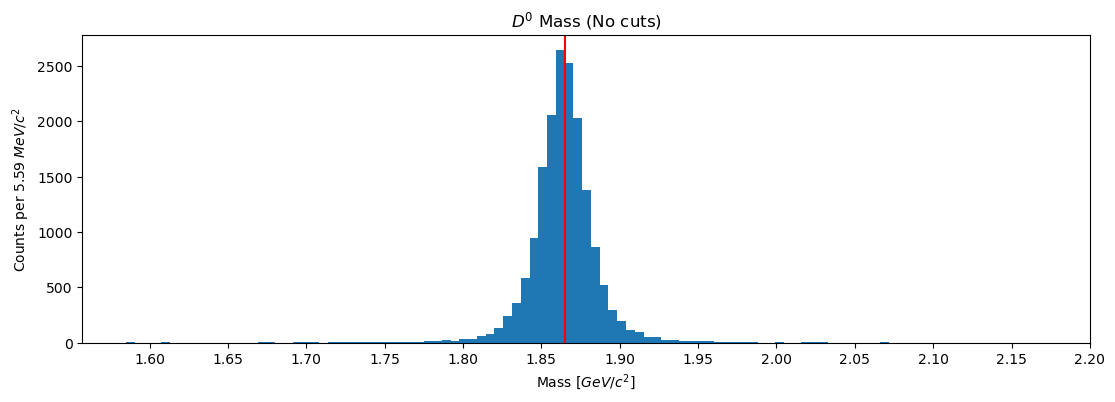

In [8]:
MIN_MASS, MAX_MASS = 0.85*m_d0, 1.15*m_d0
N_BINS = 100

fig, ax = plt.subplots(figsize=(13,4))
ax.hist(final_results["inv_mass"], bins=N_BINS, range=(MIN_MASS, MAX_MASS))
plt.axvline(x=m_d0, color="red")
plt.xlabel("Mass [$GeV/c^2$]")
plt.ylabel(f"Counts per {((MAX_MASS-MIN_MASS)/N_BINS)*1000:.2f} $MeV/c^2$")
plt.title("$D^0$ Mass (No cuts)")
plt.xticks( np.arange(1.6, 2.2, 0.05) )
#plt.savefig("D0_Mass_MC.png")
plt.show()

From the plot above we can see that the width of the mass peak is around $1.80-1.93$ $MeV/c^2$. So during the search for the $D_0$ in real data we can focus in this interval.

#### DISTRIBUTION OF $TOF_{KA}$

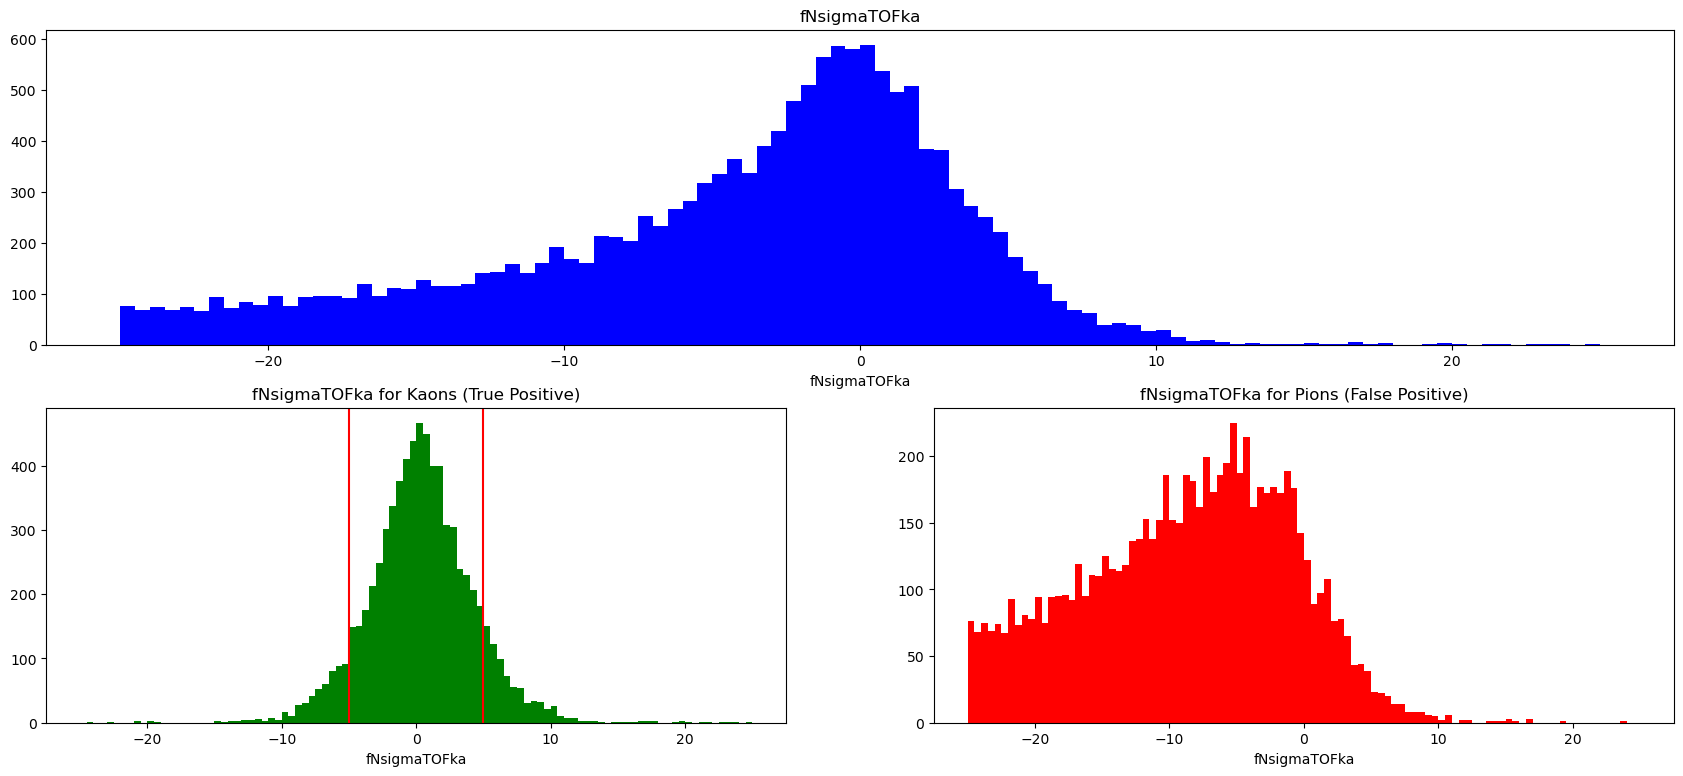

In [9]:
mosaic = [
    ["top", "top"],
    ["left", "right"]
]

fig, axes = plt.subplot_mosaic(mosaic, figsize=(21, 9))
N_BINS = 100
MIN_TOF, MAX_TOF = -25, 25
axes["top"].hist(np.concat([final_results["KA_TOFka"],final_results["PI_TOFka"]]), bins=N_BINS, color="blue", range=(MIN_TOF, MAX_TOF))
axes["top"].set_title("fNsigmaTOFka")
axes["top"].set_xlabel("fNsigmaTOFka")
axes["top"].set_label("Counts")

axes["left"].hist(final_results["KA_TOFka"], bins=N_BINS, color="green", range=(MIN_TOF, MAX_TOF))
axes["left"].set_title("fNsigmaTOFka for Kaons (True Positive)")
axes["left"].set_xlabel("fNsigmaTOFka")
axes["left"].set_label("Counts")
axes["left"].axvline(x=-5, color="red")
axes["left"].axvline(x=+5, color="red")

axes["right"].hist(final_results["PI_TOFka"], bins=N_BINS, color="red", range=(MIN_TOF, MAX_TOF))
axes["right"].set_title("fNsigmaTOFka for Pions (False Positive)")
axes["right"].set_xlabel("fNsigmaTOFka")
axes["right"].set_label("Counts")

plt.show()

From the plot above we can see that a good cut for the $TOF_{KA}$ variable is around $[-5, 5]$. So during the search for the $D_0$ in real data we can focus in this interval. In this way we can alsoexclude some false positive noise.

---KA only---
True Positive data remaining for -3 < TOF_KA < 3:     24.30%   (13827 rows eliminated.)
True Positive data remaining for -3 < TOF_KA < 3 or unavailable:     81.35%   (3406 rows eliminated.)

---All particles---
True&False Positive data remaining for -3 < TOF_KA < 3:     14.49%   (15619 rows eliminated.)
True&False Positive data remaining for -3 < TOF_KA < 3 or unavailable:     91.59%   (1536 rows eliminated.)


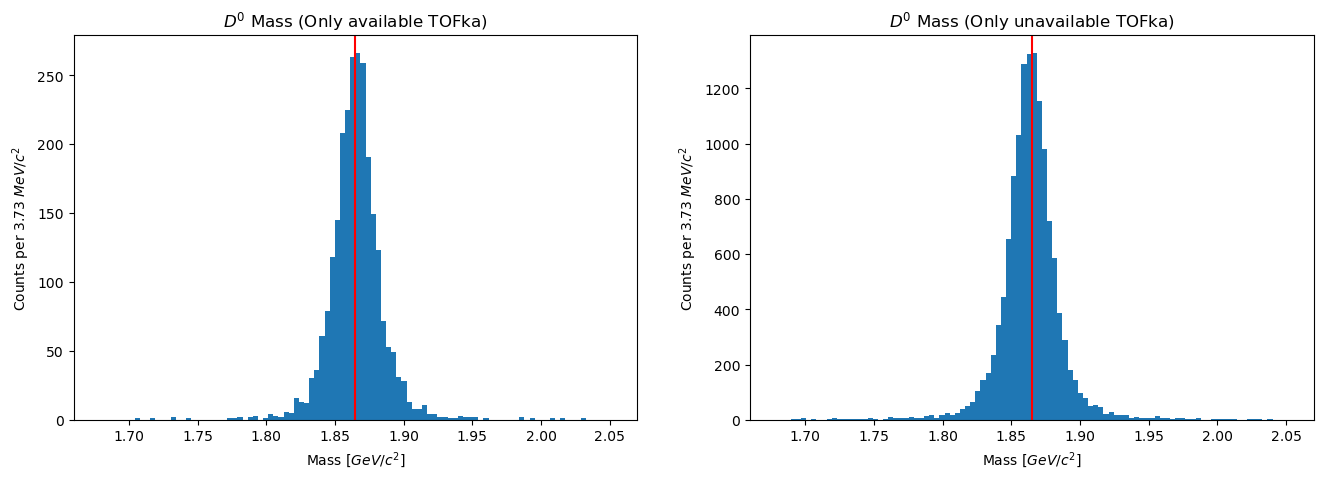

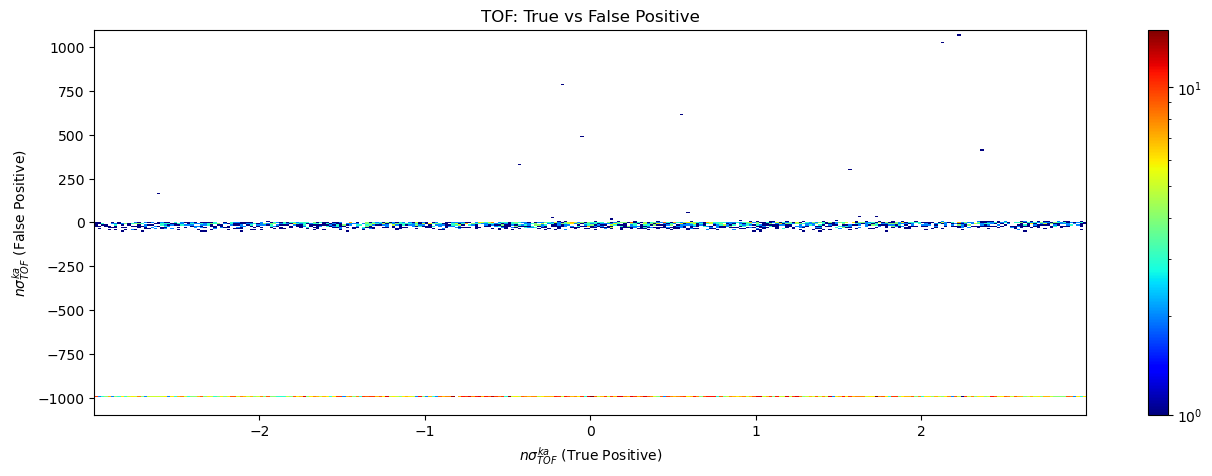

Fraction of True Positive Kaons with corresponding unavailable TOF in case of particle switch: 0.11185327128387626


In [10]:
# in cut2:
# "( (fNsigmaTOFka > -3) & (fNsigmaTOFka < 3) & (fCharge == -1) ) | "
# "( (fNsigmaTOFka > 998.5) | (fNsigmaTOFka < -998.5) |

min_cut_TOF_KA, max_cut_TOF_KA = -3, 3
NA_TOF_KA = 998.5
start_size = len(final_results)
middle_size = sum(final_results["KA_TOFka"].between(min_cut_TOF_KA, max_cut_TOF_KA))
final_size = middle_size + sum(final_results["KA_TOFka"].abs() > NA_TOF_KA )
print("---KA only---")
print(f"True Positive data remaining for {min_cut_TOF_KA} < TOF_KA < {max_cut_TOF_KA}:     {(middle_size/start_size)*100:.2f}%   ({start_size - middle_size} rows eliminated.)")
print(f"True Positive data remaining for {min_cut_TOF_KA} < TOF_KA < {max_cut_TOF_KA} or unavailable:     {(final_size/start_size)*100:.2f}%   ({start_size - final_size} rows eliminated.)")
print("\n---All particles---")
middle_size = sum( ( final_results["KA_TOFka"].between(min_cut_TOF_KA, max_cut_TOF_KA)  & (final_results["PI_TOFka"].abs() < NA_TOF_KA) ) |
                   ( final_results["PI_TOFka"].between(min_cut_TOF_KA, max_cut_TOF_KA)  & (final_results["KA_TOFka"].abs()< NA_TOF_KA) ) )
final_size = middle_size + sum( ( final_results["KA_TOFka"].abs() > NA_TOF_KA ) | ( final_results["PI_TOFka"].abs() > NA_TOF_KA ) )
print(f"True&False Positive data remaining for {min_cut_TOF_KA} < TOF_KA < {max_cut_TOF_KA}:     {(middle_size/start_size)*100:.2f}%   ({start_size - middle_size} rows eliminated.)")
print(f"True&False Positive data remaining for {min_cut_TOF_KA} < TOF_KA < {max_cut_TOF_KA} or unavailable:     {(final_size/start_size)*100:.2f}%   ({start_size - final_size} rows eliminated.)")

# Are rows corresponding to unavailable TOFka important? How does the invariant mass look without them?
only_available_TOF = final_results[( final_results["KA_TOFka"].between(min_cut_TOF_KA, max_cut_TOF_KA)  & (final_results["PI_TOFka"].abs() < NA_TOF_KA) ) |
                   ( final_results["PI_TOFka"].between(min_cut_TOF_KA, max_cut_TOF_KA)  & (final_results["KA_TOFka"].abs()< NA_TOF_KA) )]

MIN_MASS, MAX_MASS = 0.9*m_d0, 1.1*m_d0
N_BINS = 100
fig, ax  = plt.subplots(1, 2, figsize=(16,5))
ax[0].hist(only_available_TOF["inv_mass"], bins=N_BINS, range=(MIN_MASS, MAX_MASS))
ax[0].axvline(x=m_d0, color="red")
ax[0].set_xlabel("Mass [$GeV/c^2$]")
ax[0].set_ylabel(f"Counts per {((MAX_MASS-MIN_MASS)/N_BINS)*1000:.2f} $MeV/c^2$")
ax[0].set_title("$D^0$ Mass (Only available TOFka)")

# only UNAVAILABLE
only_unavailable_TOF = final_results[( final_results["KA_TOFka"].abs() > NA_TOF_KA ) | ( final_results["PI_TOFka"].abs() > NA_TOF_KA ) ]
ax[1].hist(only_unavailable_TOF["inv_mass"], bins=N_BINS, range=(MIN_MASS, MAX_MASS))
ax[1].axvline(x=m_d0, color="red")
ax[1].set_xlabel("Mass [$GeV/c^2$]")
ax[1].set_ylabel(f"Counts per {((MAX_MASS-MIN_MASS)/N_BINS)*1000:.2f} $MeV/c^2$")
ax[1].set_title("$D^0$ Mass (Only unavailable TOFka)")

plt.show()

# Check how the true positive and false positive are related
fig, ax = plt.subplots(figsize=(16,5))
plt.hist2d(final_results[( final_results["KA_TOFka"].between(min_cut_TOF_KA, max_cut_TOF_KA))]["KA_TOFka"],
           final_results[( final_results["KA_TOFka"].between(min_cut_TOF_KA, max_cut_TOF_KA))]["PI_TOFka"],
           (300, 300), cmap="jet", norm=LogNorm() )
plt.colorbar()
plt.xlabel(r"$n\sigma^{ka}_{TOF}$ (True Positive)")
plt.ylabel(r"$n\sigma^{ka}_{TOF}$ (False Positive)")
plt.ylim(-1.1*NA_TOF_KA, 1.1*NA_TOF_KA )
plt.title("TOF: True vs False Positive")
plt.show()

print("Fraction of True Positive Kaons with corresponding unavailable TOF in case of particle switch:",
      sum( (final_results["KA_TOFka"].between(min_cut_TOF_KA, max_cut_TOF_KA)) & ( (final_results["PI_TOFka"].abs() > NA_TOF_KA) ) )/len(final_results) )

It is so obvious that we can't exclude data where the TOF variable is not available, because it's the majority of the data.

#### DISTRIBUTION OF $TPC_{KA}$

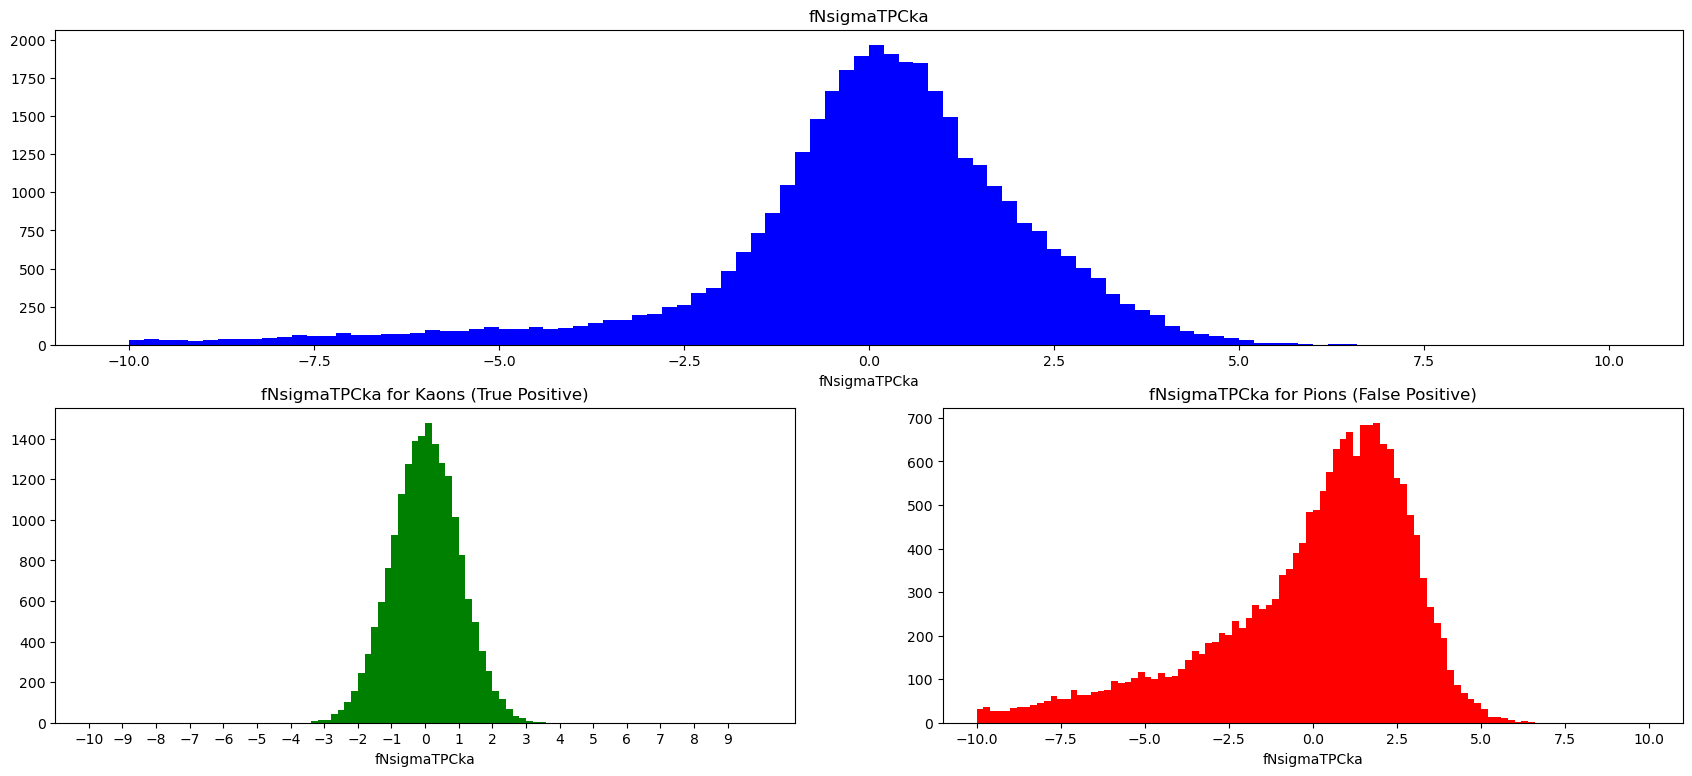

In [11]:
fig, axes = plt.subplot_mosaic(mosaic, figsize=(21, 9))
N_BINS = 100
MIN_TPC, MAX_TPC = -10, +10
axes["top"].hist(np.concat([final_results["KA_TPCka"],final_results["PI_TPCka"]]), bins=N_BINS, color="blue", range=(MIN_TPC, MAX_TPC))
axes["top"].set_title("fNsigmaTPCka")
axes["top"].set_xlabel("fNsigmaTPCka")
axes["top"].set_label("Counts")

axes["left"].hist(final_results["KA_TPCka"], bins=N_BINS, color="green", range=(MIN_TPC, MAX_TPC))
axes["left"].set_title("fNsigmaTPCka for Kaons (True Positive)")
axes["left"].set_xlabel("fNsigmaTPCka")
axes["left"].set_label("Counts")
axes["left"].set_xticks( np.arange(-10, 10, 1) )

axes["right"].hist(final_results["PI_TPCka"], bins=N_BINS, color="red", range=(MIN_TPC, MAX_TPC))
axes["right"].set_title("fNsigmaTPCka for Pions (False Positive)")
axes["right"].set_xlabel("fNsigmaTPCka")
axes["right"].set_label("Counts")

plt.show()

From the plot above we can see that a good cut for the $TOF_{KA}$ variable is around $[-2.5, 2.5]$. So during the search for the $D_0$ in real data we can focus in this interval. In this way we can alsoexclude some false positive noise.

---KA only---
True Positive data remaining for -3 < TPC_KA < 3:     99.79%   (38 rows eliminated.)

---All particles---
True&False Positive data remaining for -3 < TPC_KA < 3:     99.95%   (9 rows eliminated.)


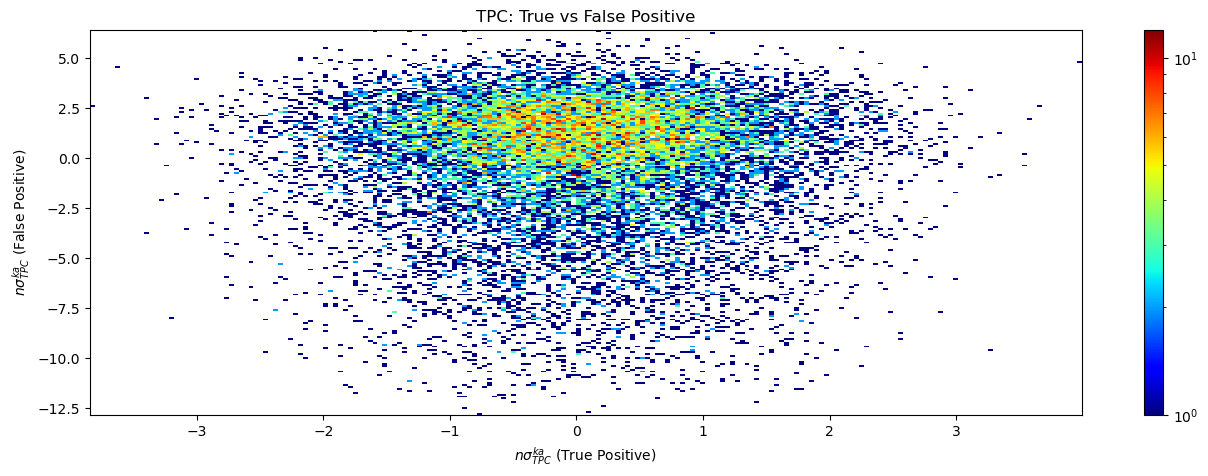

In [12]:
# in cut1:
# "( (fNsigmaTPCka > -3) & (fNsigmaTPCka < 3) & (fCharge == -1) ) | "
# "( (fPt > 0) & (fPt < 1) & (fNsigmaTPCka > -15) & (fNsigmaTPCka < 0) & (fCharge == 1) )"

min_cut_TPC_KA, max_cut_TPC_KA = -3, 3
start_size = len(final_results)
final_size = sum(final_results["KA_TPCka"].between(min_cut_TPC_KA, max_cut_TPC_KA))
print("---KA only---")
print(f"True Positive data remaining for {min_cut_TPC_KA} < TPC_KA < {max_cut_TPC_KA}:     {(final_size/start_size)*100:.2f}%   ({start_size - final_size} rows eliminated.)")
print("\n---All particles---")
final_size = sum( ( final_results["KA_TPCka"].between(min_cut_TPC_KA, max_cut_TPC_KA) ) |
                   ( final_results["PI_TPCka"].between(min_cut_TPC_KA, max_cut_TPC_KA)  ) )
print(f"True&False Positive data remaining for {min_cut_TPC_KA} < TPC_KA < {max_cut_TPC_KA}:     {(final_size/start_size)*100:.2f}%   ({start_size - final_size} rows eliminated.)")

# Check how the true positive and false positive are related
fig, ax = plt.subplots(figsize=(16,5))
plt.hist2d(final_results["KA_TPCka"], final_results["PI_TPCka"], (200, 200), cmap="jet", norm=LogNorm() )
plt.colorbar()
plt.xlabel(r"$n\sigma^{ka}_{TPC}$ (True Positive)")
plt.ylabel(r"$n\sigma^{ka}_{TPC}$ (False Positive)")
plt.title("TPC: True vs False Positive")
plt.show()

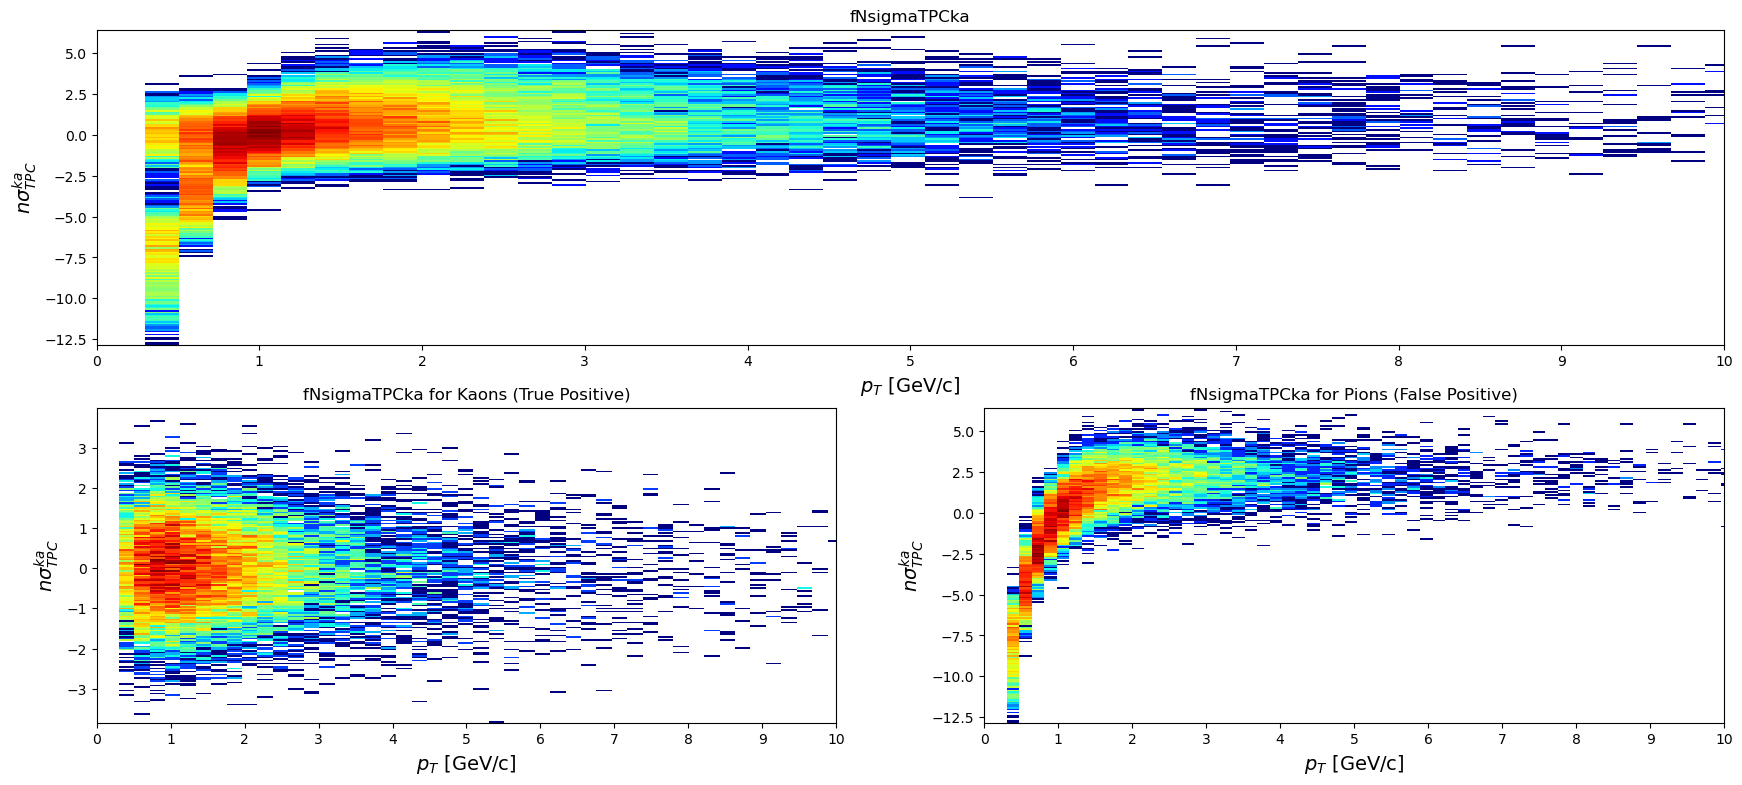

In [13]:
fs = 14
p_cut_lower = 0
p_cut_upper = 10
fig, axes = plt.subplot_mosaic(mosaic, figsize=(21, 9))
axes["top"].hist2d(np.concat([final_results["KA_pt"], final_results["PI_pt"]]),
                    np.concat([final_results["KA_TPCka"], final_results["PI_TPCka"]]), (200, 200), cmap="jet", norm=LogNorm())
# plt.colorbar(ax=axes["top"])
axes["top"].set_xlabel(r"$p_{T}$ [GeV/c]", fontsize=fs)
axes["top"].set_ylabel(r"$n\sigma^{ka}_{TPC}$", fontsize=fs)
axes["top"].set_xlim(p_cut_lower, p_cut_upper )
axes["top"].set_xticks(np.arange(p_cut_lower, p_cut_upper+1, 1) )
axes["top"].set_title("fNsigmaTPCka")


axes["left"].hist2d(final_results["KA_pt"], final_results["KA_TPCka"], (200, 200), cmap="jet", norm=LogNorm())
# plt.colorbar(ax=axes["left"])
axes["left"].set_xlabel(r"$p_{T}$ [GeV/c]", fontsize=fs)
axes["left"].set_ylabel(r"$n\sigma^{ka}_{TPC}$", fontsize=fs)
axes["left"].set_xlim(p_cut_lower, p_cut_upper )
axes["left"].set_xticks(np.arange(p_cut_lower, p_cut_upper+1, 1) )
axes["left"].set_title("fNsigmaTPCka for Kaons (True Positive)")

axes["right"].hist2d(final_results["PI_pt"], final_results["PI_TPCka"], (200, 200), cmap="jet", norm=LogNorm())
# plt.colorbar(ax=axes["left"])
axes["right"].set_xlabel(r"$p_{T}$ [GeV/c]", fontsize=fs)
axes["right"].set_ylabel(r"$n\sigma^{ka}_{TPC}$", fontsize=fs)
axes["right"].set_xlim(p_cut_lower, p_cut_upper )
axes["right"].set_xticks(np.arange(p_cut_lower, p_cut_upper+1, 1) )
axes["right"].set_title("fNsigmaTPCka for Pions (False Positive)")

plt.show()

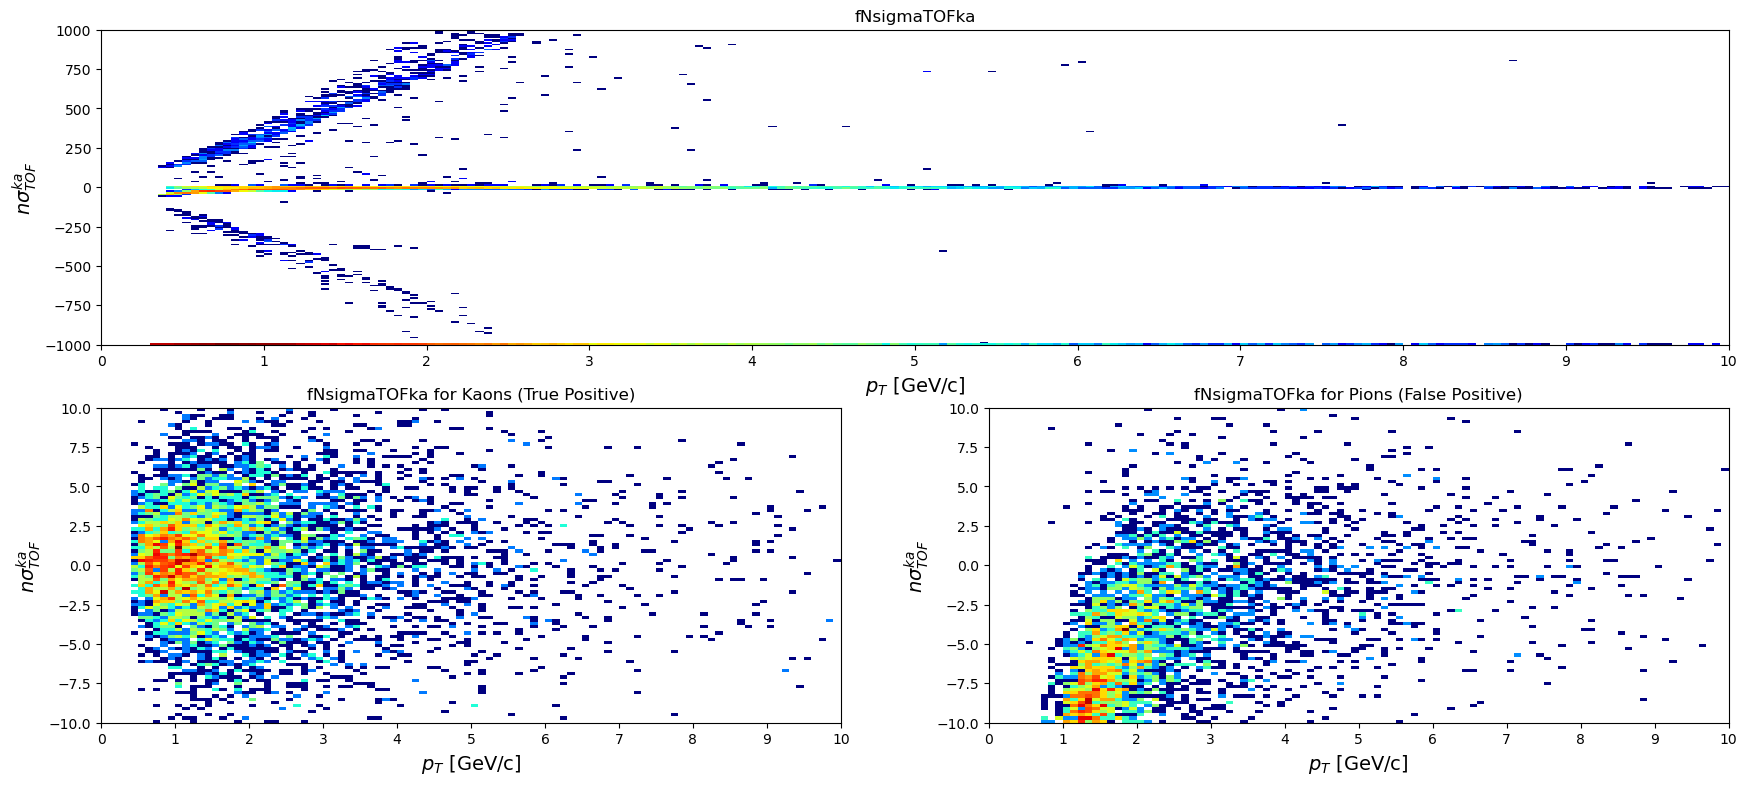

In [14]:
fs = 14
p_cut_lower = 0
p_cut_upper = 10
TOF_lower, TOF_upper = -1000, +1000
fig, axes = plt.subplot_mosaic(mosaic, figsize=(21, 9))
axes["top"].hist2d(np.concat([final_results["KA_pt"], final_results["PI_pt"]]),
                    np.concat([final_results["KA_TOFka"], final_results["PI_TOFka"]]), (200, 200), cmap="jet", norm=LogNorm(),
                    range = ([[p_cut_lower,p_cut_upper],[TOF_lower,TOF_upper]]))
# plt.colorbar(ax=axes["top"])
axes["top"].set_xlabel(r"$p_{T}$ [GeV/c]", fontsize=fs)
axes["top"].set_ylabel(r"$n\sigma^{ka}_{TOF}$", fontsize=fs)
axes["top"].set_xlim(p_cut_lower, p_cut_upper )
axes["top"].set_xticks(np.arange(p_cut_lower, p_cut_upper+1, 1) )
axes["top"].set_title("fNsigmaTOFka")


axes["left"].hist2d(final_results["KA_pt"], final_results["KA_TOFka"], (100, 100), cmap="jet", norm=LogNorm(),
                    range = ([[p_cut_lower,p_cut_upper],[-10,10]]))
# plt.colorbar(ax=axes["left"])
axes["left"].set_xlabel(r"$p_{T}$ [GeV/c]", fontsize=fs)
axes["left"].set_ylabel(r"$n\sigma^{ka}_{TOF}$", fontsize=fs)
axes["left"].set_xlim(p_cut_lower, p_cut_upper )
axes["left"].set_xticks(np.arange(p_cut_lower, p_cut_upper+1, 1) )
axes["left"].set_title("fNsigmaTOFka for Kaons (True Positive)")

axes["right"].hist2d(final_results["PI_pt"], final_results["PI_TOFka"], (100, 100), cmap="jet", norm=LogNorm(),
                     range = ([[p_cut_lower,p_cut_upper],[-10,10]]))
# plt.colorbar(ax=axes["left"])
axes["right"].set_xlabel(r"$p_{T}$ [GeV/c]", fontsize=fs)
axes["right"].set_ylabel(r"$n\sigma^{ka}_{TOF}$", fontsize=fs)
axes["right"].set_xlim(p_cut_lower, p_cut_upper )
axes["right"].set_xticks(np.arange(p_cut_lower, p_cut_upper+1, 1) )
axes["right"].set_title("fNsigmaTOFka for Pions (False Positive)")

plt.show()

#### DISTRIBUTION OF $TOF_{pi}$

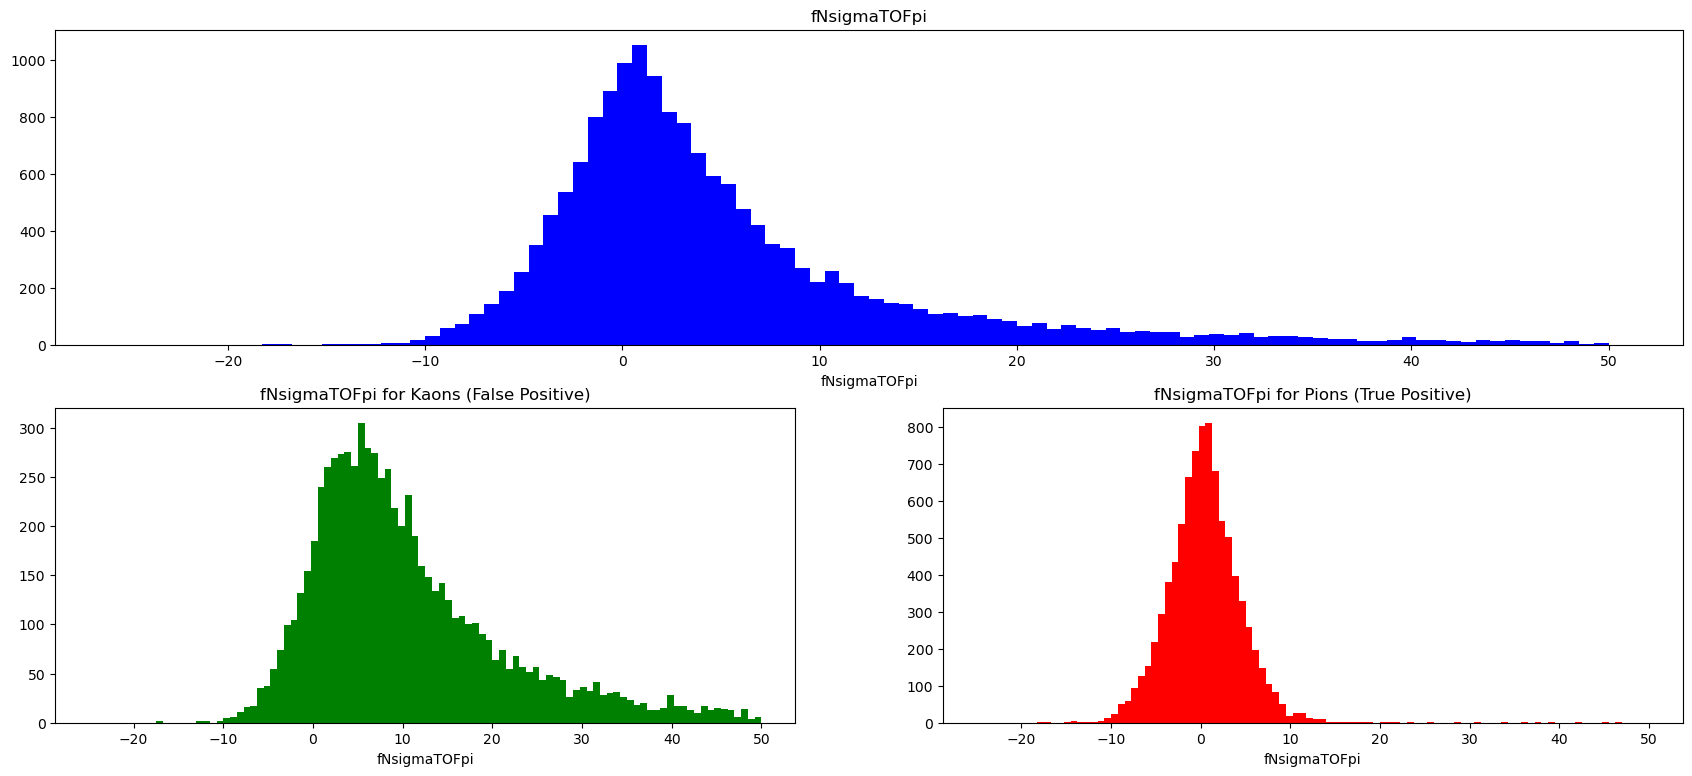

In [15]:
fig, axes = plt.subplot_mosaic(mosaic, figsize=(21, 9))
N_BINS = 100
MIN_TOF, MAX_TOF = -25, 50
axes["top"].hist(np.concat([final_results["KA_TOFpi"],final_results["PI_TOFpi"]]), bins=N_BINS, color="blue", range=(MIN_TOF, MAX_TOF))
axes["top"].set_title("fNsigmaTOFpi")
axes["top"].set_xlabel("fNsigmaTOFpi")
axes["top"].set_label("Counts")

axes["left"].hist(final_results["KA_TOFpi"], bins=N_BINS, color="green", range=(MIN_TOF, MAX_TOF))
axes["left"].set_title("fNsigmaTOFpi for Kaons (False Positive)")
axes["left"].set_xlabel("fNsigmaTOFpi")
axes["left"].set_label("Counts")

axes["right"].hist(final_results["PI_TOFpi"], bins=N_BINS, color="red", range=(MIN_TOF, MAX_TOF))
axes["right"].set_title("fNsigmaTOFpi for Pions (True Positive)")
axes["right"].set_xlabel("fNsigmaTOFpi")
axes["right"].set_label("Counts")

plt.show()

The result is a bit strange, the values of $TOF_{pi}$ doesn't seem to be concentrated around 0 as they should.
The cut won't be very useful. We can choose $[-10,50]$.

---Pion only---
True Positive data remaining for -10 < TOF_PI < 50:     48.29%   (9444 rows eliminated.)
True Positive data remaining for -10 < TOF_PI < 50 or unavailable:     99.41%   (107 rows eliminated.)

---All particles---
True&False Positive data remaining for -3 < TOF_PI < 3:     21.47%   (14344 rows eliminated.)
True&False Positive data remaining for -3 < TOF_PI < 3 or unavailable:     99.84%   (30 rows eliminated.)


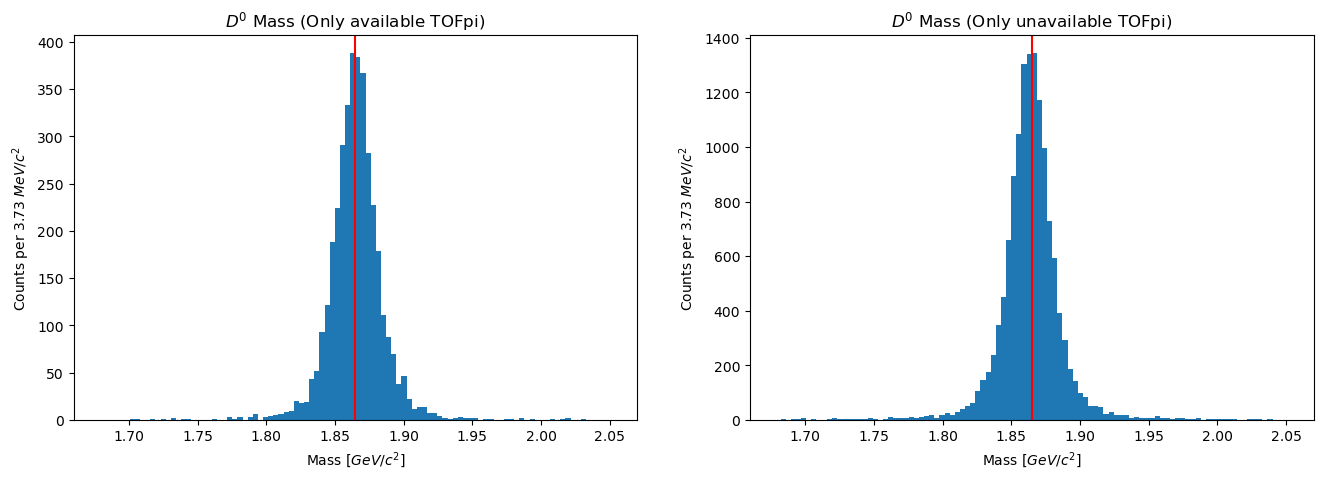

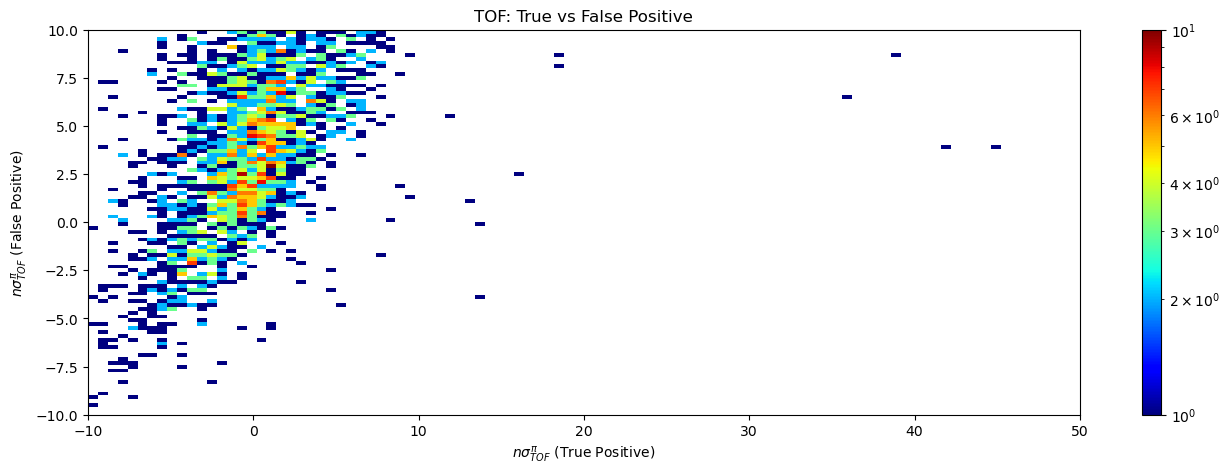

Fraction of True Positive Pions with corresponding unavailable TOF in case of particle switch: 0.2693128935121818


In [16]:
# in cut2:
# "( (fNsigmaTOFpi > -3) & (fNsigmaTOFpi < 3) & (fCharge == 1) ) | "
# "(fNsigmaTOFpi > 998.5) | (fNsigmaTOFpi < -998.5) ) | "

min_cut_TOF_PI, max_cut_TOF_PI = -10, 50
NA_TOF_PI = 998.5
start_size = len(final_results)
middle_size = sum(final_results["PI_TOFpi"].between(min_cut_TOF_PI, max_cut_TOF_PI))
final_size = middle_size + sum(final_results["PI_TOFpi"].abs() > NA_TOF_PI )
print("---Pion only---")
print(f"True Positive data remaining for {min_cut_TOF_PI} < TOF_PI < {max_cut_TOF_PI}:     {(middle_size/start_size)*100:.2f}%   ({start_size - middle_size} rows eliminated.)")
print(f"True Positive data remaining for {min_cut_TOF_PI} < TOF_PI < {max_cut_TOF_PI} or unavailable:     {(final_size/start_size)*100:.2f}%   ({start_size - final_size} rows eliminated.)")
print("\n---All particles---")
middle_size = sum( ( final_results["KA_TOFpi"].between(min_cut_TOF_PI, max_cut_TOF_PI)  & (final_results["PI_TOFpi"].abs() < NA_TOF_PI) ) |
                   ( final_results["PI_TOFpi"].between(min_cut_TOF_PI, max_cut_TOF_PI)  & (final_results["KA_TOFpi"].abs()< NA_TOF_PI) ) )
final_size = middle_size + sum( ( final_results["KA_TOFpi"].abs() > NA_TOF_PI ) | ( final_results["PI_TOFpi"].abs() > NA_TOF_PI ) )
print(f"True&False Positive data remaining for {min_cut_TOF_KA} < TOF_PI < {max_cut_TOF_KA}:     {(middle_size/start_size)*100:.2f}%   ({start_size - middle_size} rows eliminated.)")
print(f"True&False Positive data remaining for {min_cut_TOF_KA} < TOF_PI < {max_cut_TOF_KA} or unavailable:     {(final_size/start_size)*100:.2f}%   ({start_size - final_size} rows eliminated.)")

# Are rows corresponding to unavailable TOFpi important? How does the invariant mass look without them?
only_available_TOF = final_results[( final_results["KA_TOFpi"].between(min_cut_TOF_PI, max_cut_TOF_PI)  & (final_results["PI_TOFpi"].abs() < NA_TOF_PI) ) |
                   ( final_results["PI_TOFpi"].between(min_cut_TOF_PI, max_cut_TOF_PI)  & (final_results["KA_TOFpi"].abs()< NA_TOF_PI) )]

MIN_MASS, MAX_MASS = 0.9*m_d0, 1.1*m_d0
N_BINS = 100
fig, ax  = plt.subplots(1, 2, figsize=(16,5))
ax[0].hist(only_available_TOF["inv_mass"], bins=N_BINS, range=(MIN_MASS, MAX_MASS))
ax[0].axvline(x=m_d0, color="red")
ax[0].set_xlabel("Mass [$GeV/c^2$]")
ax[0].set_ylabel(f"Counts per {((MAX_MASS-MIN_MASS)/N_BINS)*1000:.2f} $MeV/c^2$")
ax[0].set_title("$D^0$ Mass (Only available TOFpi)")

# only UNAVAILABLE
only_unavailable_TOF = final_results[( final_results["KA_TOFpi"].abs() > NA_TOF_PI ) | ( final_results["PI_TOFpi"].abs() > NA_TOF_PI ) ]
ax[1].hist(only_unavailable_TOF["inv_mass"], bins=N_BINS, range=(MIN_MASS, MAX_MASS))
ax[1].axvline(x=m_d0, color="red")
ax[1].set_xlabel("Mass [$GeV/c^2$]")
ax[1].set_ylabel(f"Counts per {((MAX_MASS-MIN_MASS)/N_BINS)*1000:.2f} $MeV/c^2$")
ax[1].set_title("$D^0$ Mass (Only unavailable TOFpi)")

plt.show()

test = final_results[final_results["PI_TOFpi"].between(min_cut_TOF_PI, max_cut_TOF_PI)]
test = test[test["KA_TOFpi"].between(-10,10)]

# Check how the true positive and false positive are related
fig, ax = plt.subplots(figsize=(16,5))
# plt.hist2d(final_results[( final_results["PI_TOFpi"].between(min_cut_TOF_PI, max_cut_TOF_PI))]["PI_TOFpi"],
#            final_results[( final_results["PI_TOFpi"].between(min_cut_TOF_PI, max_cut_TOF_PI))]["KA_TOFpi"],
#            (400, 400), cmap="jet", norm=LogNorm() )
plt.hist2d(test["PI_TOFpi"],
           test["KA_TOFpi"],
           (100, 100), cmap="jet", norm=LogNorm(), range=[[-10, 50], [-10, 10]] )

plt.colorbar()
plt.xlabel(r"$n\sigma^{\pi}_{TOF}$ (True Positive)")
plt.ylabel(r"$n\sigma^{\pi}_{TOF}$ (False Positive)")
#plt.ylim(-1.1*NA_TOF_PI, 1.1*NA_TOF_PI )
plt.title("TOF: True vs False Positive")
plt.show()

print("Fraction of True Positive Pions with corresponding unavailable TOF in case of particle switch:",
      sum( (final_results["PI_TOFpi"].between(min_cut_TOF_PI, max_cut_TOF_PI)) & ( (final_results["KA_TOFpi"].abs() > NA_TOF_PI) ) )/len(final_results) )

It is so obvious that we can't exclude data where the TOF variable is not available, because it's the majority of the data.

#### DISTRIBUTION OF $TPC_{pi}$

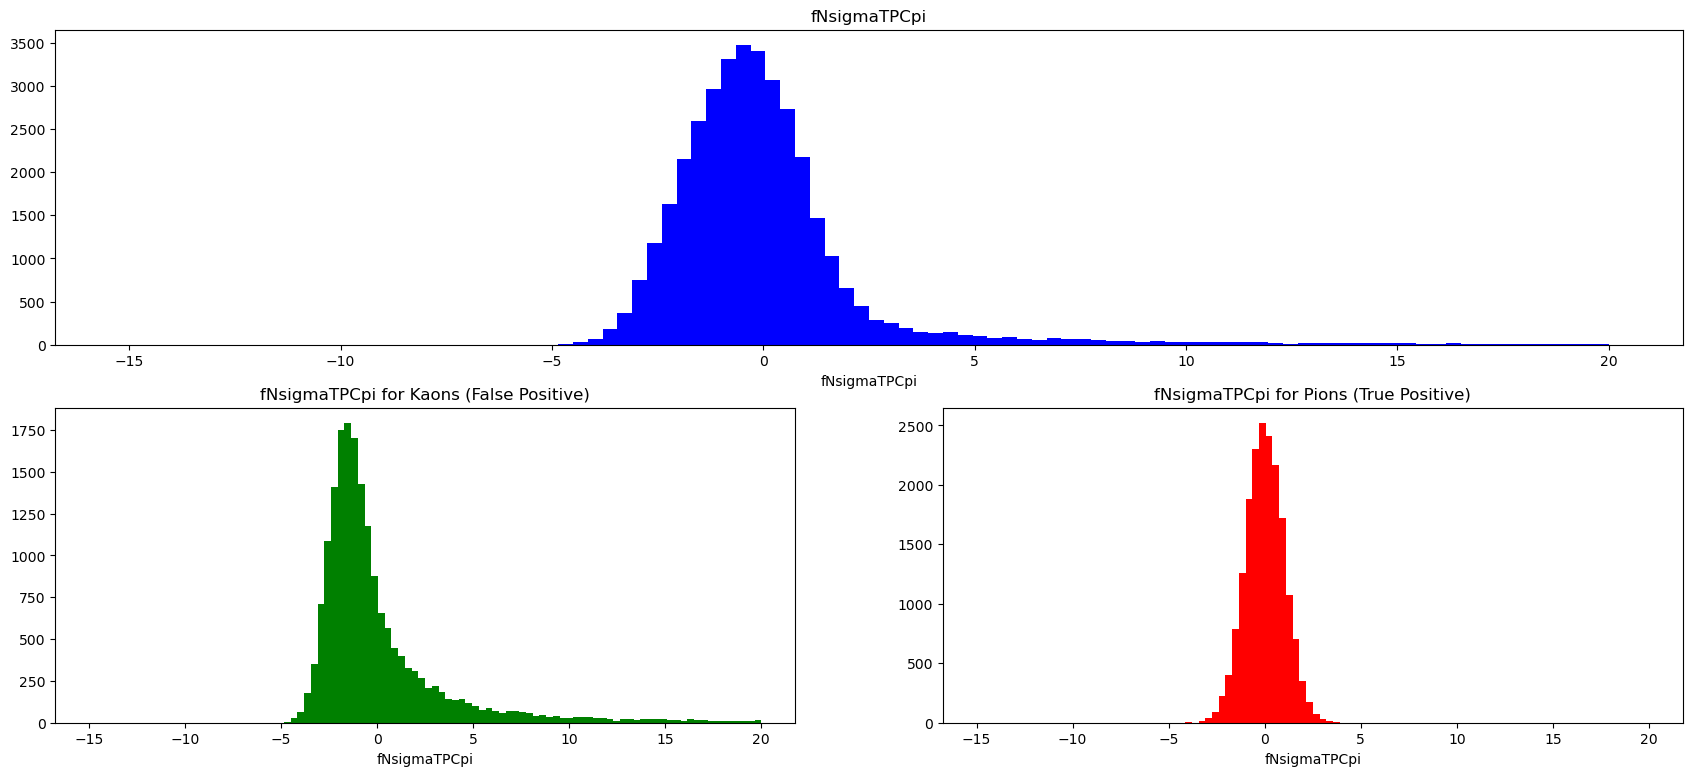

In [17]:
fig, axes = plt.subplot_mosaic(mosaic, figsize=(21, 9))
N_BINS = 100
MIN_TPC, MAX_TPC = -15, +20
axes["top"].hist(np.concat([final_results["KA_TPCpi"],final_results["PI_TPCpi"]]), bins=N_BINS, color="blue", range=(MIN_TPC, MAX_TPC))
axes["top"].set_title("fNsigmaTPCpi")
axes["top"].set_xlabel("fNsigmaTPCpi")
axes["top"].set_label("Counts")

axes["left"].hist(final_results["KA_TPCpi"], bins=N_BINS, color="green", range=(MIN_TPC, MAX_TPC))
axes["left"].set_title("fNsigmaTPCpi for Kaons (False Positive)")
axes["left"].set_xlabel("fNsigmaTPCpi")
axes["left"].set_label("Counts")

axes["right"].hist(final_results["PI_TPCpi"], bins=N_BINS, color="red", range=(MIN_TPC, MAX_TPC))
axes["right"].set_title("fNsigmaTPCpi for Pions (True Positive)")
axes["right"].set_xlabel("fNsigmaTPCpi")
axes["right"].set_label("Counts")

plt.show()

From the plot above we can see that a good cut for the $TPC_{pi}$ variable is around $[-4.5, 15]$. So during the search for the $D_0$ in real data we can focus in this interval.

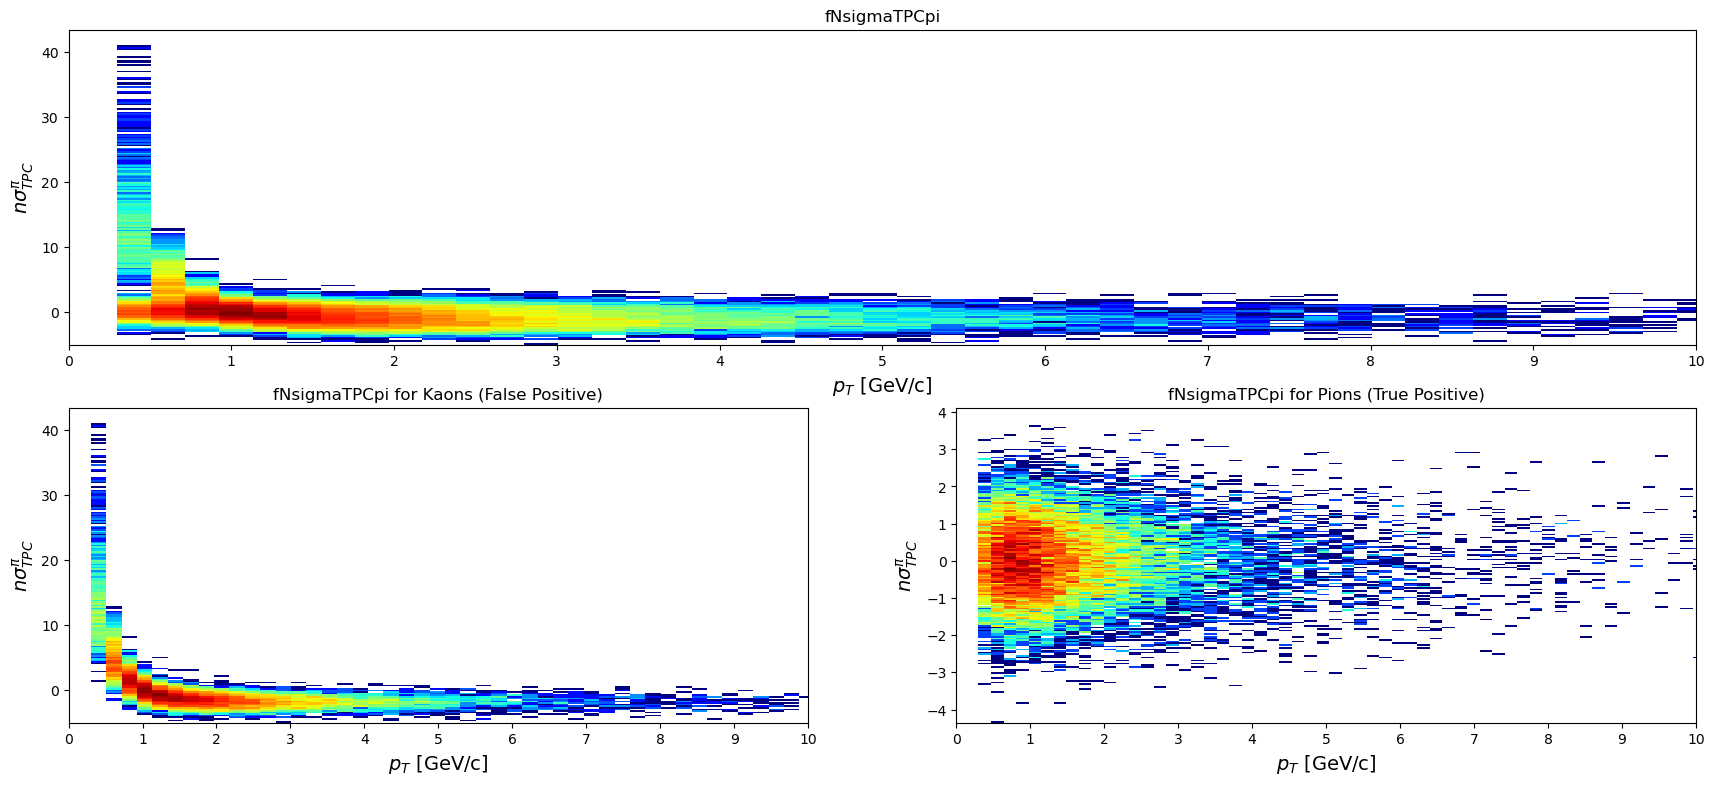

In [18]:
fs = 14
p_cut_lower = 0
p_cut_upper = 10
fig, axes = plt.subplot_mosaic(mosaic, figsize=(21, 9))
axes["top"].hist2d(np.concat([final_results["KA_pt"], final_results["PI_pt"]]),
                    np.concat([final_results["KA_TPCpi"], final_results["PI_TPCpi"]]), (200, 200), cmap="jet", norm=LogNorm())
# plt.colorbar(ax=axes["top"])
axes["top"].set_xlabel(r"$p_{T}$ [GeV/c]", fontsize=fs)
axes["top"].set_ylabel(r"$n\sigma^{\pi}_{TPC}$", fontsize=fs)
axes["top"].set_xlim(p_cut_lower, p_cut_upper )
axes["top"].set_xticks(np.arange(p_cut_lower, p_cut_upper+1, 1) )
axes["top"].set_title("fNsigmaTPCpi")


axes["left"].hist2d(final_results["KA_pt"], final_results["KA_TPCpi"], (200, 200), cmap="jet", norm=LogNorm())
# plt.colorbar(ax=axes["left"])
axes["left"].set_xlabel(r"$p_{T}$ [GeV/c]", fontsize=fs)
axes["left"].set_ylabel(r"$n\sigma^{\pi}_{TPC}$", fontsize=fs)
axes["left"].set_xlim(p_cut_lower, p_cut_upper )
axes["left"].set_xticks(np.arange(p_cut_lower, p_cut_upper+1, 1) )
axes["left"].set_title("fNsigmaTPCpi for Kaons (False Positive)")

axes["right"].hist2d(final_results["PI_pt"], final_results["PI_TPCpi"], (200, 200), cmap="jet", norm=LogNorm())
# plt.colorbar(ax=axes["left"])
axes["right"].set_xlabel(r"$p_{T}$ [GeV/c]", fontsize=fs)
axes["right"].set_ylabel(r"$n\sigma^{\pi}_{TPC}$", fontsize=fs)
axes["right"].set_xlim(p_cut_lower, p_cut_upper )
axes["right"].set_xticks(np.arange(p_cut_lower, p_cut_upper+1, 1) )
axes["right"].set_title("fNsigmaTPCpi for Pions (True Positive)")

plt.show()

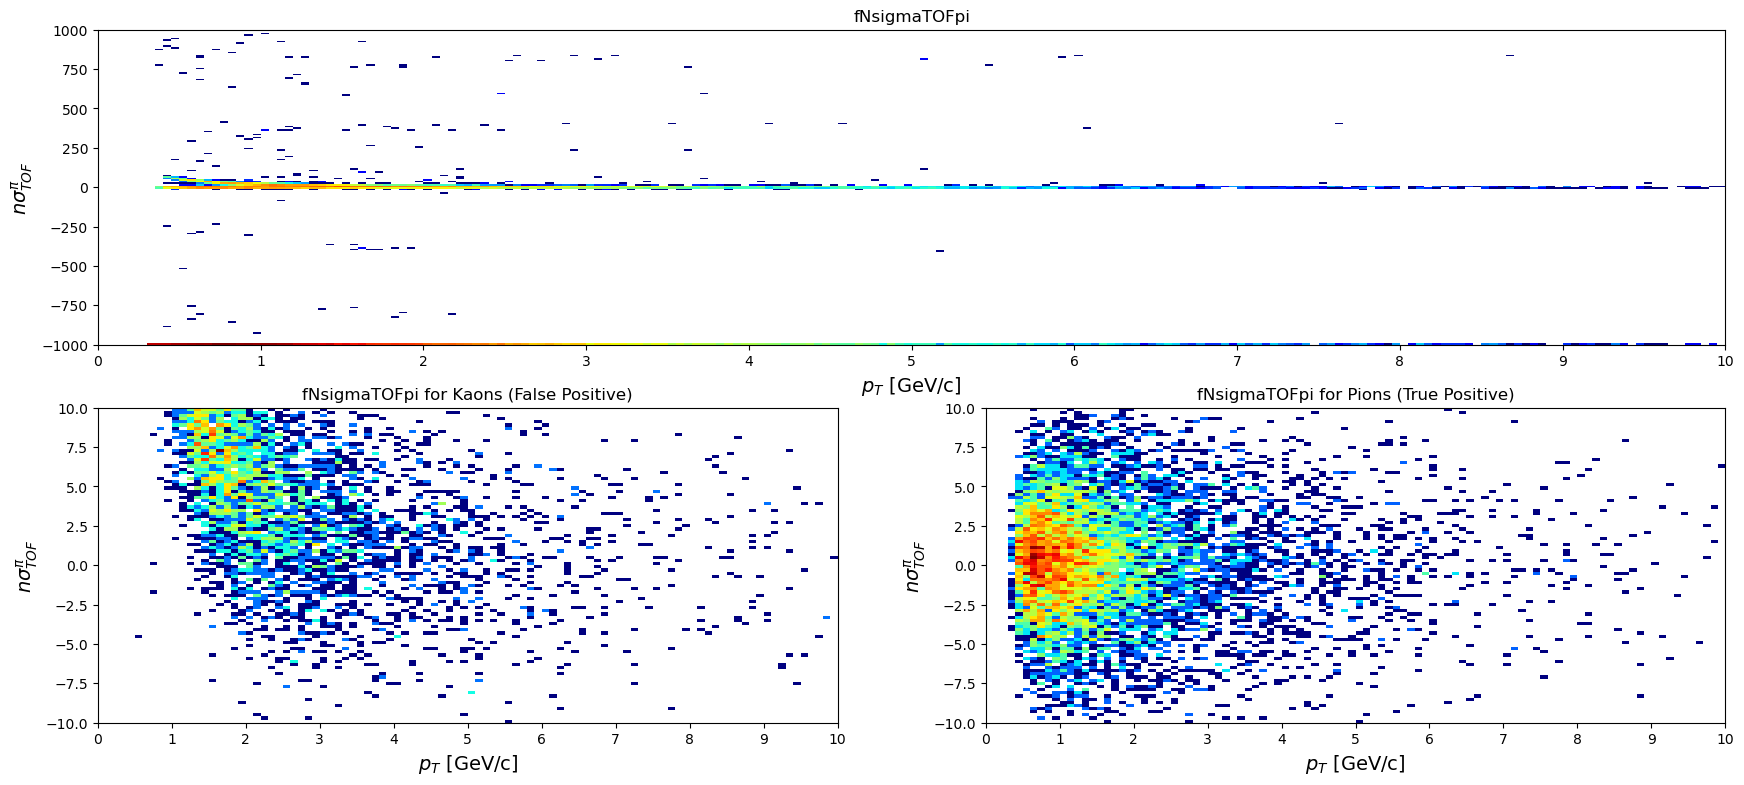

In [19]:
fs = 14
p_cut_lower = 0
p_cut_upper = 10
TOF_lower, TOF_upper = -1000, +1000
fig, axes = plt.subplot_mosaic(mosaic, figsize=(21, 9))
axes["top"].hist2d(np.concat([final_results["KA_pt"], final_results["PI_pt"]]),
                    np.concat([final_results["KA_TOFpi"], final_results["PI_TOFpi"]]), (200, 200), cmap="jet", norm=LogNorm(),
                    range = ([[p_cut_lower,p_cut_upper],[TOF_lower,TOF_upper]]))
# plt.colorbar(ax=axes["top"])
axes["top"].set_xlabel(r"$p_{T}$ [GeV/c]", fontsize=fs)
axes["top"].set_ylabel(r"$n\sigma^{\pi}_{TOF}$", fontsize=fs)
axes["top"].set_xlim(p_cut_lower, p_cut_upper )
axes["top"].set_xticks(np.arange(p_cut_lower, p_cut_upper+1, 1) )
axes["top"].set_title("fNsigmaTOFpi")


axes["left"].hist2d(final_results["KA_pt"], final_results["KA_TOFpi"], (100, 100), cmap="jet", norm=LogNorm(),
                    range = ([[p_cut_lower,p_cut_upper],[-10,10]]))
# plt.colorbar(ax=axes["left"])
axes["left"].set_xlabel(r"$p_{T}$ [GeV/c]", fontsize=fs)
axes["left"].set_ylabel(r"$n\sigma^{\pi}_{TOF}$", fontsize=fs)
axes["left"].set_xlim(p_cut_lower, p_cut_upper )
axes["left"].set_xticks(np.arange(p_cut_lower, p_cut_upper+1, 1) )
axes["left"].set_title("fNsigmaTOFpi for Kaons (False Positive)")

axes["right"].hist2d(final_results["PI_pt"], final_results["PI_TOFpi"], (100, 100), cmap="jet", norm=LogNorm(),
                     range = ([[p_cut_lower,p_cut_upper],[-10,10]]))
# plt.colorbar(ax=axes["left"])
axes["right"].set_xlabel(r"$p_{T}$ [GeV/c]", fontsize=fs)
axes["right"].set_ylabel(r"$n\sigma^{\pi}_{TOF}$", fontsize=fs)
axes["right"].set_xlim(p_cut_lower, p_cut_upper )
axes["right"].set_xticks(np.arange(p_cut_lower, p_cut_upper+1, 1) )
axes["right"].set_title("fNsigmaTOFpi for Pions (True Positive)")

plt.show()

### DISTRIBUTION IN $p_t$ and $DCA_{xy}$

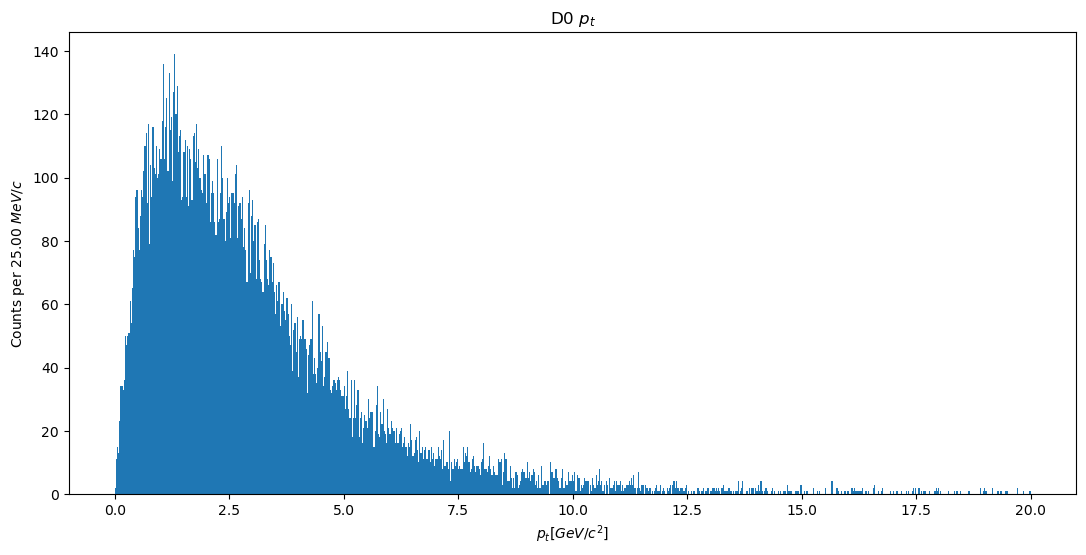

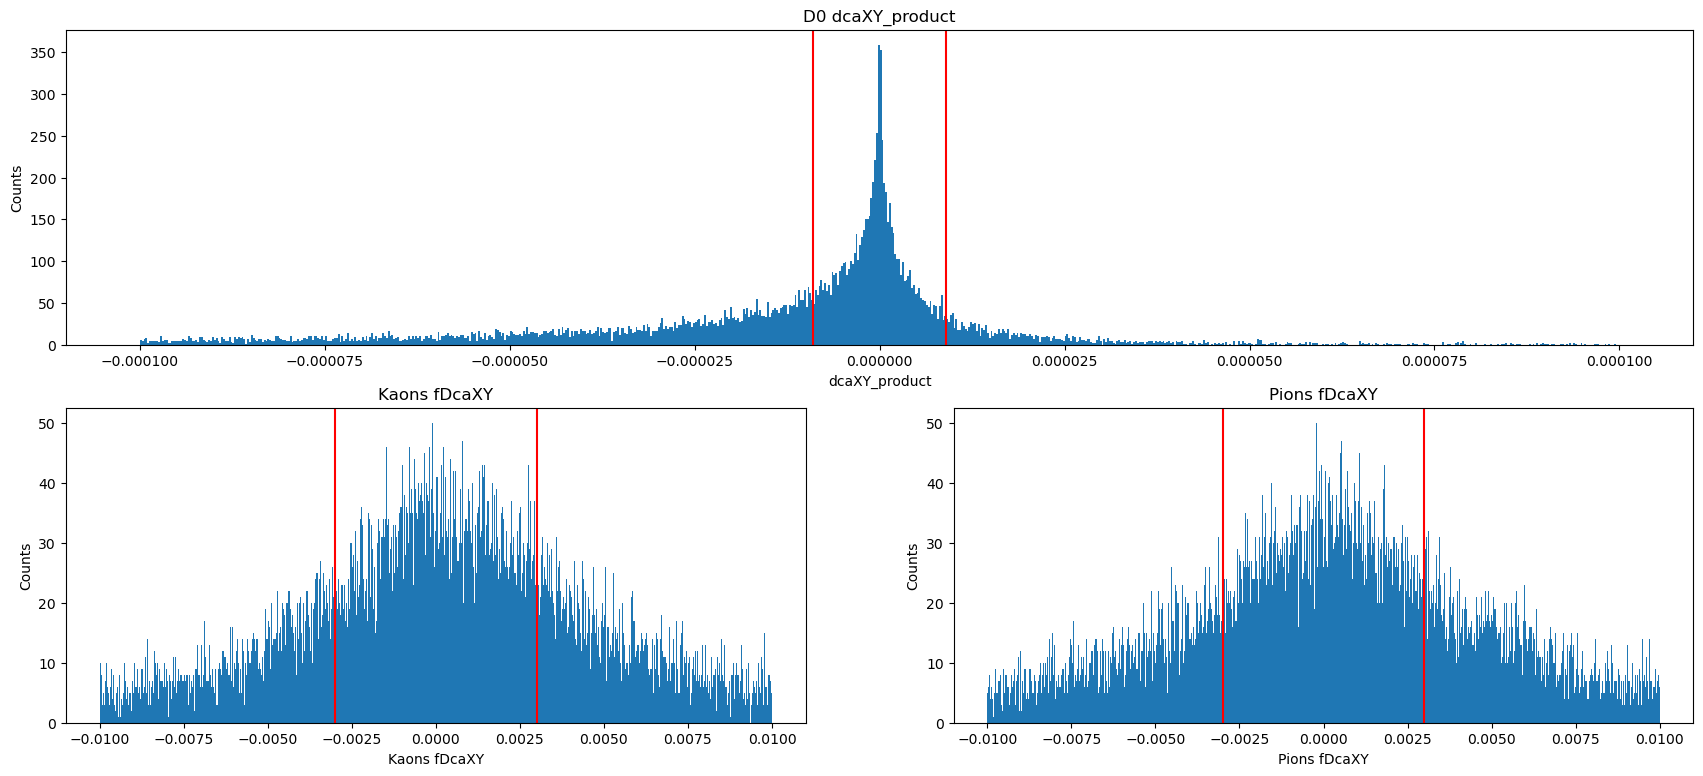

In [20]:
MIN_pt, MAX_pt = 0, 20
N_BINS = 800

fig, ax = plt.subplots(figsize=(13,6))
ax.hist(final_results["pt"], range=(MIN_pt, MAX_pt), bins=N_BINS)
plt.xlabel("$p_t [GeV/c^2]$")
plt.ylabel(f"Counts per {((MAX_pt -  MIN_pt)/N_BINS)*1000:.2f} $MeV/c$")
plt.title("D0 $p_t$")
plt.show()

# MIN_DCAXY, MAX_DCAXY = np.quantile(final_results["dcaXY_product"], 0.01), np.quantile(final_results["dcaXY_product"], 0.99)
MIN_DCAXY, MAX_DCAXY = -1e-04, +1e-04
fig, axes = plt.subplot_mosaic(mosaic, figsize=(21, 9))
axes["top"].hist(final_results["dcaXY_product"], bins=N_BINS, range=(MIN_DCAXY, MAX_DCAXY))
axes["top"].set_xlabel("dcaXY_product")
axes["top"].set_ylabel(f"Counts")
axes["top"].set_title("D0 dcaXY_product")
axes["top"].axvline(x=-3e-03**2, color="red")
axes["top"].axvline(x=+3e-03**2, color="red")

axes["left"].hist(final_results["KA_fDcaXY"], bins=N_BINS, range=(-np.sqrt(-MIN_DCAXY),np.sqrt(MAX_DCAXY)))
axes["left"].set_xlabel("Kaons fDcaXY")
axes["left"].set_ylabel(f"Counts")
axes["left"].set_title("Kaons fDcaXY")
axes["left"].axvline(x=-3e-03, color="red")
axes["left"].axvline(x=+3e-03, color="red")

axes["right"].hist(final_results["PI_fDcaXY"], bins=N_BINS, range=(-np.sqrt(-MIN_DCAXY),np.sqrt(MAX_DCAXY)))
axes["right"].set_xlabel("Pions fDcaXY")
axes["right"].set_ylabel(f"Counts")
axes["right"].set_title("Pions fDcaXY")
axes["right"].axvline(x=-3e-03, color="red")
axes["right"].axvline(x=+3e-03, color="red")
plt.show()

#### DECAY LENGTH

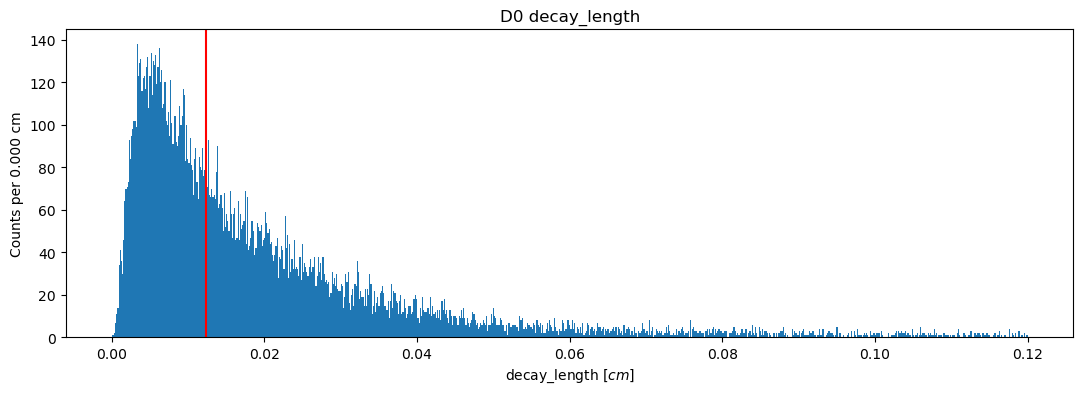

In [28]:
MIN_dl, MAX_dl = 0, 0.12
N_BINS = 800

fig, ax = plt.subplots(figsize=(13,4))
ax.hist(final_results["decay_length"], bins=N_BINS, range=(MIN_dl, MAX_dl))
plt.xlabel("decay_length $[cm]$")
plt.ylabel(f"Counts per {((MAX_dl - MIN_dl)/N_BINS):.3f} cm")
plt.axvline(x=1.23*10**(-2), color="red")
plt.title("D0 decay_length")
plt.show()

A good cut here could be $[0,0.4]$.

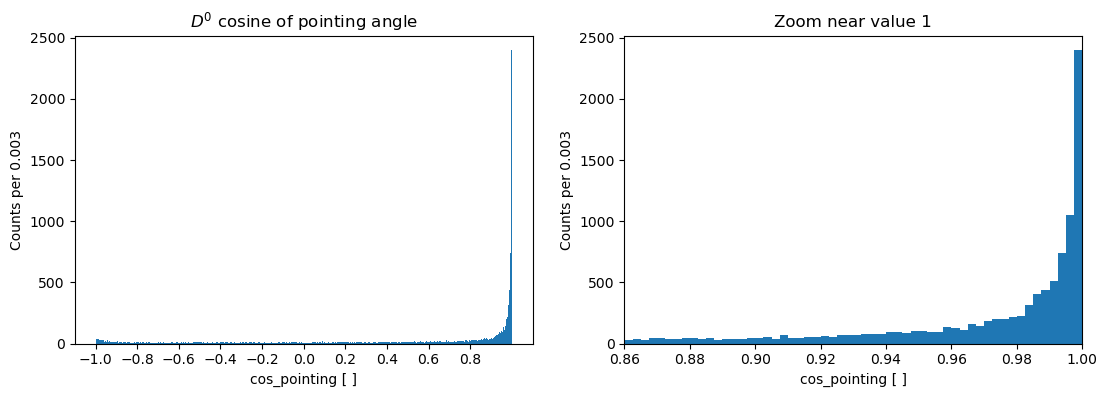

In [39]:
MIN_cos, MAX_cos = -1, 1
N_BINS = 800

fig, axes = plt.subplots(1,2, figsize=(13,4))

axes[0].hist(final_results["cos_pointing"], bins=N_BINS, range=(MIN_cos, MAX_cos))
axes[0].set_xlabel("cos_pointing [ ]")
axes[0].set_ylabel(f"Counts per {((MAX_cos - MIN_cos)/N_BINS):.3f}")
axes[0].set_title("$D^0$ cosine of pointing angle")
axes[0].set_xticks( np.arange(-1, 1, 0.2) )

axes[1].hist(final_results["cos_pointing"], bins=N_BINS, range=(MIN_cos, MAX_cos))
axes[1].set_xlabel("cos_pointing [ ]")
axes[1].set_ylabel(f"Counts per {((MAX_cos - MIN_cos)/N_BINS):.3f}")
axes[1].set_title("Zoom near value 1")
axes[1].set_xlim([0.86,1])
axes[1].set_xticks( np.arange(0.86, 1, 0.02) )

plt.show()



A good cut here could be $[0.96,1]$.